# Laboratorio 6 — Análisis de redes sociales (YouTube)
### CC3084 — Data Science | Universidad del Valle de Guatemala | Semestre II — 2026

**Avance:** Incisos 1 y 2 (Carga/integración de datos, y Calidad/limpieza/preprocesamiento)

Este notebook cubre:
1. Carga, comprensión e integración de los datos (`youtube_videos.csv`, `youtube_comments.csv`)
2. Calidad, limpieza y preprocesamiento (diagnóstico, normalización de IDs, conversión de conteos, limpieza de texto)

> Nota metodológica: los datos **no permiten identificar quién respondió a quién**. `reply_count` indica cuántas respuestas recibió un comentario principal, pero no identifica a los autores de esas respuestas ni su contenido, por lo que en ningún punto de este análisis se interpreta como una arista entre usuarios.


In [1]:
# Librerías generales
import pandas as pd
import numpy as np
import ast
import re
import json
import unicodedata

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', 80)

RANDOM_STATE = 42


## 1. Carga, comprensión e integración de los datos

### 1.1 Carga de los archivos `youtube_videos.csv` y `youtube_comments.csv`

In [2]:
videos = pd.read_csv('data/youtube_videos.csv')
comments = pd.read_csv('data/youtube_comments.csv')

print(f"videos: {videos.shape[0]} filas x {videos.shape[1]} columnas")
print(f"comments: {comments.shape[0]} filas x {comments.shape[1]} columnas")


videos: 293 filas x 20 columnas
comments: 406 filas x 17 columnas


In [3]:
videos.head(3)

,video_id,title,channel_name,channel_id,source_query,source_group,dataset_sources,channel_handle,published_time,view_count_text,description_snippet,video_url,query_hits,keywords,description,view_count,publish_date,upload_date,category,owner_handle
0,-5puKGEqcUc,INSIVUMEH pronostica incremento de lluvias para el fin de semana en Guatemala,T13 Noticias Guatemala,UCq0Cm-3SKthEySQc2JZBi1A,guatemala lluvias,topic,youtube_guatemala.csv | youtube_guatemala_lab.csv | youtube_guatemala_plus.csv,/@T13NoticiasGuatemala,hace 2 días,"2,390 vistas",El Departamento de Pronóstico de INSIVUMEH prevé un incremento en las lluvia...,https://www.youtube.com/watch?v=-5puKGEqcUc,"[""guatemala lluvias""]","[""Canícula prolongada"", ""Chapin tv"", ""Fenómeno del Niño"", ""Guatemala"", ""Lluv...",El Departamento de Pronóstico de INSIVUMEH prevé un incremento en las lluvia...,2357,2026-08-28T22:00:20-07:00,2026-08-28T22:00:20-07:00,News & Politics,/@T13NoticiasGuatemala
1,-E7OPOLjMug,BERNARDO ARÉVALO CALIFICA CAMBIO EN EL MP COMO EL FIN DE UNA ETAPA DE DETERI...,IDocumenta,UCgItjn_ZWFWcv1MlpKIkqgQ,@GobiernodelaRepublicadeGuatema,topic,youtube_target_channels.csv,/@iDocumenta,hace 3 meses,4 vistas,"El presidente de Guatemala, Bernardo Arévalo, calificó el cambio de fiscal g...",https://www.youtube.com/watch?v=-E7OPOLjMug,"[""@GobiernodelaRepublicadeGuatema""]",[],"El presidente de Guatemala, Bernardo Arévalo, calificó el cambio de fiscal g...",4,2026-05-13T16:00:03-07:00,2026-05-13T16:00:03-07:00,People & Blogs,/@iDocumenta
2,-KDglrIzRKo,¡HISTÓRICO! Mexico recupera petróleo robado por Guatemala... 🔔,México Poder,UC-DpoeBbCMOMOH1-j71KPqA,guatemala noticias,topic,youtube_guatemala.csv | youtube_guatemala_lab.csv | youtube_guatemala_plus.csv,/@M%C3%A9xicoPoder,hace 1 día,"29,736 vistas",México #PetróleoMexicano #SoberaníaEnergética #Pemex #NoticiasMéxico #Fronte...,https://www.youtube.com/watch?v=-KDglrIzRKo,"[""guatemala noticias""]","[""Mexico recupera petroleo"", ""petroleo robado Guatemala"", ""huachicol fronter...",#México #PetróleoMexicano #SoberaníaEnergética #Pemex #NoticiasMéxico #Front...,29736,2026-08-29T17:00:38-07:00,2026-08-29T17:00:38-07:00,People & Blogs,/@M%C3%A9xicoPoder


In [4]:
comments.head(3)

,video_id,comment_id,video_title,channel_name,channel_id,author_name,author_channel_id,text,source_query,source_group,dataset_sources,author_handle,published_text,like_count_text,reply_count,is_pinned,viewer_rating
0,j43HgwYFKfk,Ugw-J65a1iYL9hqhELh4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@MarcosCarillo-b1r,UCdFlugHJJa4l3YqWuNRmvXw,Ese corrupto amigo de la vieja fiscal los tengo que verbose en la carcel,@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete_comments.csv | youtube_guatem...,/@MarcosCarillo-b1r,hace 6 meses,,0,False,NaN
1,06mFNPU0aB8,Ugw-ZT9t9wU2V-tCaUZ4AaABAg,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer ...,Noti7,UCVpSRoZgngfSL03Nlbjtq9A,@RaulPerez-cw2vi,UCvl1tzQeBeGy6efPTRJXSCw,"Están jóvenes porque no buscan un trabajo, tuvieron suerte que no hay polic...",guatemala noticias,topic,youtube_guatemala_comments.csv | youtube_guatemala_plus_comments.csv,/@RaulPerez-cw2vi,hace 2 semanas,,0,False,NaN
2,j43HgwYFKfk,Ugw0xaOb2CYXXoudtwJ4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@iamjimalesssa,UCRAquv8el-tQ30bN7MlmySQ,"Me dejaron con ganas de demandar la ilegalidad de las reuniones virtuales, e...",@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete_comments.csv | youtube_guatem...,/@iamjimalesssa,hace 1 año,4,0,False,NaN


### 1.2 Unidad de observación, llave primaria y variables relevantes

**`youtube_videos.csv`**
- **Unidad de observación:** un video de YouTube recuperado durante la recolección.
- **Llave primaria:** `video_id` (identificador único de video en YouTube; verificado sin duplicados abajo).
- **Variables relevantes:**
  - Identificación del video/canal: `video_id`, `channel_id` (preferido sobre `channel_name`, que puede repetirse), `channel_handle`.
  - Contenido: `title`, `description`, `description_snippet`, `keywords`.
  - Popularidad: `view_count` (numérica, apta para cálculo), `view_count_text` (texto crudo de YouTube).
  - Procedencia/muestreo: `source_query`, `source_group`, `query_hits`, `dataset_sources`.
  - Temporalidad: `publish_date` / `upload_date` (ISO 8601, idénticas entre sí) y `published_time` (texto relativo, dependiente del momento de scraping).
  - Categoría: `category` (categoría asignada por YouTube).

**`youtube_comments.csv`**
- **Unidad de observación:** un comentario **principal** publicado en un video (no incluye respuestas/replies).
- **Llave primaria:** `comment_id` (identificador único de comentario; verificado sin duplicados abajo).
- **Llave foránea:** `video_id`, que conecta cada comentario con su video en `youtube_videos.csv`.
- **Variables relevantes:**
  - Identificación del autor: `author_channel_id` (identificador único y estable del autor; debe preferirse a `author_name`/`author_handle`, que pueden cambiar o repetirse).
  - Contenido: `text` (variable principal para tópicos y sentimiento).
  - Popularidad/interacción: `like_count_text` (texto, requiere limpieza), `reply_count` (numérica, **no** identifica autores de las respuestas).
  - Procedencia: `source_query`, `source_group`, `dataset_sources`.
  - Temporalidad: `published_text` (texto relativo).
  - Variables no utilizables: `is_pinned` (constante, siempre `False`) y `viewer_rating` (100% nula).


In [5]:
# Verificación de llaves primarias (sin duplicados)
print("Duplicados en video_id (videos):   ", videos['video_id'].duplicated().sum())
print("Duplicados en comment_id (comments):", comments['comment_id'].duplicated().sum())


Duplicados en video_id (videos):    0
Duplicados en comment_id (comments): 0


### 1.3 Relación entre canal, video, autor del comentario, comentario, categoría y consulta de búsqueda

La estructura relacional del conjunto de datos es la siguiente:

- Un **canal** (`channel_id`) puede publicar **muchos videos** (relación 1 → N). Cada video pertenece a un único canal.
- Un **video** (`video_id`) puede recibir **muchos comentarios** (relación 1 → N, vía `video_id` como llave foránea en `comments`). En este conjunto, 274 de los 293 videos no tienen comentarios asociados (cobertura parcial — ver limitaciones).
- Un **autor de comentario** (`author_channel_id`) puede publicar **comentarios en varios videos distintos** (relación N → M entre autores y videos), lo cual es precisamente la base de la red bipartita autor-video que se construirá en incisos posteriores.
- Cada video tiene asignada una **categoría** de YouTube (`category`), una variable categórica que describe el tipo de contenido (p. ej. *News & Politics*, *People & Blogs*).
- La **consulta de búsqueda** (`source_query`) describe el *procedimiento de muestreo*: el término o canal utilizado para encontrar el video durante la recolección. Un mismo video puede coincidir con varias consultas (`query_hits`), y `source_group` indica si el video se encontró por tema (`topic`), por ser un canal de gobierno (`official_gov`) o por canal específico (`channel`). **Importante:** la consulta de búsqueda describe *cómo* se encontró el contenido, no necesariamente *de qué trata* — dos videos con la misma consulta pueden ser de temas distintos, y el mismo canal se encuentra tanto en `videos` como en `comments` a través de `channel_id`, que es consistente entre ambos archivos (validado abajo).

En síntesis: **canal → video → comentario → autor**, con `category` y `source_query` como atributos descriptivos de video, no como entidades con llave propia.


In [6]:
# Validación: el channel_id asociado a un comentario (vía su video) es
# consistente con el channel_id del video en 'videos'
chk = comments.merge(videos[['video_id', 'channel_id']], on='video_id',
                      suffixes=('_comment_video', '_videos_file'))
inconsistencias = (chk['channel_id_comment_video'] != chk['channel_id_videos_file']).sum()
print(f"Inconsistencias channel_id (comments vs videos) tras el join: {inconsistencias} / {len(chk)}")

print(f"\nCanales únicos en videos.csv: {videos['channel_id'].nunique()}")
print(f"Autores únicos (author_channel_id) en comments.csv: {comments['author_channel_id'].nunique()}")


Inconsistencias channel_id (comments vs videos) tras el join: 0 / 406

Canales únicos en videos.csv: 97
Autores únicos (author_channel_id) en comments.csv: 332


### 1.4 Integración de los conjuntos mediante `video_id`

In [7]:
# Integración: cada comentario se enriquece con los atributos de su video
df = comments.merge(
    videos,
    on='video_id',
    how='left',
    suffixes=('_comment', '_video')
)

comentarios_asociados = df['title'].notna().sum()  # 'title' solo existe si hubo match con videos
print(f"Comentarios totales:              {len(comments)}")
print(f"Comentarios asociados a un video: {comentarios_asociados}")
print(f"Comentarios sin video asociado:   {len(comments) - comentarios_asociados}")


Comentarios totales:              406
Comentarios asociados a un video: 406
Comentarios sin video asociado:   0


**Resultado:** los 406 comentarios (100%) pudieron asociarse correctamente a un video mediante `video_id`, lo cual es consistente con la validación de la sección 1.3 (todo `video_id` presente en `comments.csv` existe en `videos.csv`). El DataFrame integrado `df` tiene una fila por comentario, enriquecida con los atributos del video correspondiente (título, canal, categoría, visualizaciones, etc.), y se usará como base para el análisis exploratorio del inciso 3.

In [8]:
print(f"df integrado: {df.shape[0]} filas x {df.shape[1]} columnas")
df[['comment_id', 'video_id', 'author_channel_id', 'title', 'category', 'view_count']].head(5)

df integrado: 406 filas x 36 columnas


,comment_id,video_id,author_channel_id,title,category,view_count
0,Ugw-J65a1iYL9hqhELh4AaABAg,j43HgwYFKfk,UCdFlugHJJa4l3YqWuNRmvXw,La cooptación de Walter Mazariegos en la USAC,News & Politics,10156
1,Ugw-ZT9t9wU2V-tCaUZ4AaABAg,06mFNPU0aB8,UCvl1tzQeBeGy6efPTRJXSCw,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer ...,News & Politics,6692
2,Ugw0xaOb2CYXXoudtwJ4AaABAg,j43HgwYFKfk,UCRAquv8el-tQ30bN7MlmySQ,La cooptación de Walter Mazariegos en la USAC,News & Politics,10156
3,Ugw0xgUc2ISpBr5_T654AaABAg,j43HgwYFKfk,UCkbsS_3D-pvg1iHOld9uvIg,La cooptación de Walter Mazariegos en la USAC,News & Politics,10156
4,Ugw1ZzA21njWhaqQQTh4AaABAg,OkXlHx0hx-8,UCOLHH4ZpMxPYF-Q6e6wvn5A,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México...,News & Politics,14200


## 2. Calidad, limpieza y preprocesamiento

### 2.1 Diagnóstico inicial de calidad

In [9]:
def diagnostico_calidad(df_, nombre):
    print(f"{'='*70}\nDIAGNÓSTICO: {nombre}\n{'='*70}")
    print(f"Dimensiones: {df_.shape[0]} filas x {df_.shape[1]} columnas\n")

    print("Tipos de variables:")
    print(df_.dtypes.value_counts(), "\n")

    print("Valores faltantes por columna (solo columnas con > 0):")
    faltantes = df_.isnull().sum()
    faltantes = faltantes[faltantes > 0].sort_values(ascending=False)
    if len(faltantes):
        print(faltantes)
    else:
        print("(ninguna)")
    print()

    print(f"Filas duplicadas (todas las columnas): {df_.duplicated().sum()}")
    return faltantes

falt_videos = diagnostico_calidad(videos, "youtube_videos.csv")


DIAGNÓSTICO: youtube_videos.csv
Dimensiones: 293 filas x 20 columnas

Tipos de variables:
object    19
int64      1
Name: count, dtype: int64 

Valores faltantes por columna (solo columnas con > 0):
description            26
description_snippet    25
view_count_text        13
published_time         13
dtype: int64

Filas duplicadas (todas las columnas): 0


In [10]:
falt_comments = diagnostico_calidad(comments, "youtube_comments.csv")

DIAGNÓSTICO: youtube_comments.csv
Dimensiones: 406 filas x 17 columnas

Tipos de variables:
object     14
int64       1
bool        1
float64     1
Name: count, dtype: int64 

Valores faltantes por columna (solo columnas con > 0):
viewer_rating    406
dtype: int64

Filas duplicadas (todas las columnas): 0


In [11]:
# Variables constantes (una sola categoría en todo el dataset)
def variables_constantes(df_, nombre):
    constantes = [c for c in df_.columns if df_[c].nunique(dropna=False) == 1]
    print(f"Variables constantes en {nombre}: {constantes}")
    return constantes

const_videos = variables_constantes(videos, "videos")
const_comments = variables_constantes(comments, "comments")


Variables constantes en videos: []
Variables constantes en comments: ['is_pinned', 'viewer_rating']


In [12]:
# Consistencia entre identificadores, nombres y handles
print("videos.csv:")
print(f"  channel_name -> ¿biyectivo con channel_id?  ",
      (videos.groupby('channel_name')['channel_id'].nunique() > 1).sum() == 0
      and (videos.groupby('channel_id')['channel_name'].nunique() > 1).sum() == 0)
print(f"  ¿owner_handle == channel_handle en el 100%%?  {(videos['owner_handle'] == videos['channel_handle']).all()}")
print(f"  ¿publish_date == upload_date en el 100%%?     {(videos['publish_date'] == videos['upload_date']).all()}")

print("\ncomments.csv:")
print(f"  author_name -> ¿biyectivo con author_channel_id?  ",
      (comments.groupby('author_name')['author_channel_id'].nunique() > 1).sum() == 0
      and (comments.groupby('author_channel_id')['author_name'].nunique() > 1).sum() == 0)


videos.csv:
  channel_name -> ¿biyectivo con channel_id?   True
  ¿owner_handle == channel_handle en el 100%%?  True
  ¿publish_date == upload_date en el 100%%?     True

comments.csv:
  author_name -> ¿biyectivo con author_channel_id?   True


In [13]:
# Valores atípicos: view_count (videos) y reply_count (comments)
print("view_count (videos) - percentiles:")
print(videos['view_count'].quantile([0, .01, .25, .5, .75, .95, .99, 1]).astype(int))

q1, q3 = videos['view_count'].quantile([.25, .75])
iqr = q3 - q1
lim_sup = q3 + 1.5 * iqr
atipicos_view = (videos['view_count'] > lim_sup).sum()
print(f"\nLímite superior IQR: {lim_sup:,.0f}  ->  {atipicos_view} videos por encima ({atipicos_view/len(videos):.1%})")

print("\nreply_count (comments) - distribución:")
print(comments['reply_count'].value_counts().sort_index())


view_count (videos) - percentiles:
0.00          2
0.01          3
0.25        215
0.50       1175
0.75       7465
0.95     130466
0.99     523972
1.00    8190449
Name: view_count, dtype: int64

Límite superior IQR: 18,340  ->  49 videos por encima (16.7%)

reply_count (comments) - distribución:
reply_count
0    376
1     21
2      3
3      4
5      1
7      1
Name: count, dtype: int64


**Hallazgos del diagnóstico:**
- No hay filas duplicadas completas ni `video_id`/`comment_id` duplicados en ninguno de los dos archivos.
- Los valores faltantes se concentran en variables de texto secundarias de `videos.csv` (`published_time`, `view_count_text`: 13 nulos cada una; `description_snippet`: 25; `description`: 26) y en `viewer_rating` de `comments.csv` (406/406, es decir, 100%).
- `is_pinned` (comments) es **constante** (`False` en todos los registros): no aporta variabilidad y se descarta del análisis.
- `channel_name` ↔ `channel_id` y `author_name` ↔ `author_channel_id` son consistentes (relación 1 a 1) en este conjunto, aunque por definición del laboratorio se prefieren los identificadores (`channel_id`, `author_channel_id`) por ser más estables.
- `owner_handle`/`channel_handle` y `publish_date`/`upload_date` son idénticas al 100%, por lo que son redundantes.
- `view_count` presenta una distribución muy asimétrica (long tail): la mediana es 1,175 vistas pero el máximo es 8,190,449; usando el criterio de rango intercuartílico hay videos con visualizaciones marcadamente atípicas (viral outliers), consistentes con la naturaleza de YouTube y no con errores de captura.
- `reply_count` está dominado por ceros (mediana 0), con un máximo de 7 respuestas por comentario.


### 2.2 Variables problemáticas o de uso delicado

| Variable | Problema | Tratamiento |
|---|---|---|
| `is_pinned` (comments) | Constante (100% `False`) | Se documenta y se excluye del análisis; no discrimina nada. |
| `viewer_rating` (comments) | 100% nula | Se descarta por completo, no puede usarse. |
| `channel_name`, `author_name`, `channel_handle`, `author_handle` | Pueden cambiar o repetirse en el tiempo; no son identificadores únicos | Se conservan **solo** como etiquetas visuales/de despliegue; para construir nodos de red y agrupar se usan siempre `channel_id` / `author_channel_id`. |
| `published_time` (videos), `published_text` (comments) | Fechas **relativas** ("hace 2 días"), dependientes del momento de recolección — no son fechas exactas reconstruibles con precisión | Se documentan como no aptas para análisis temporal fino; para videos existe la alternativa exacta `publish_date` (ISO 8601), que se usa en su lugar. Para comentarios no existe una fecha exacta equivalente, por lo que cualquier análisis temporal de comentarios queda limitado a la categoría relativa observada. |
| `upload_date` (videos) | 100% idéntica a `publish_date` | Redundante; se conserva `publish_date` como referencia y se documenta la redundancia (no se elimina la columna original del CSV, solo no se usa duplicada). |
| `owner_handle` (videos) | 100% idéntica a `channel_handle` | Redundante, mismo tratamiento que el punto anterior. |
| `view_count_text`, `like_count_text` | Texto con separadores de miles y sufijos (`"2,390 vistas"`), o vacíos (`" "`) | Se convierten a variables numéricas (`view_count` ya viene numérica en videos; `like_count_text` se limpia y convierte en la sección 2.4). |
| `query_hits`, `keywords`, `dataset_sources` (videos) y `dataset_sources` (comments) | Texto con estructura de lista (`'["a", "b"]'` o separado por `|`) | Se parsean a listas de Python (`ast.literal_eval` / `split('|')`) antes de cualquier análisis de frecuencia. |
| `text` (comments) | Contiene URLs, menciones, hashtags, emojis y errores ortográficos típicos de comentarios de YouTube | Se conserva el texto original (`texto_original`) para auditoría/sentimiento, y se genera una versión limpia (`texto_limpio`) para análisis de tópicos/frecuencia (sección 2.5–2.6). |
| `view_count` (videos) | Fuertemente asimétrica, con outliers de alta visibilidad ("virales") | No se eliminan los outliers: son observaciones reales y relevantes para el análisis de popularidad; se documentan y se usan escalas apropiadas (p. ej. logarítmica) al graficar. |
| `reply_count` (comments) | Podría malinterpretarse como relación entre usuarios | Se usa **únicamente** como conteo agregado de respuestas al comentario principal; explícitamente **no** se construye ninguna arista de red a partir de esta variable, siguiendo la advertencia del enunciado. |


### 2.3 Normalización de identificadores y nombres

Se conservan los identificadores (`channel_id`, `video_id`, `comment_id`, `author_channel_id`) como llaves de análisis, y se normalizan los nombres/handles solo con fines de **despliegue** (nunca se sustituyen los IDs por nombres visibles).


In [14]:
def normalizar_texto_visible(s):
    """Normaliza espacios en textos visibles (nombres/handles) sin alterar
    su contenido semántico ni usarlos como identificador."""
    if pd.isna(s):
        return s
    s = str(s).strip()
    s = re.sub(r'\s+', ' ', s)
    return s

for col in ['channel_name', 'channel_handle']:
    videos[col] = videos[col].apply(normalizar_texto_visible)

for col in ['channel_name', 'author_name', 'author_handle']:
    comments[col] = comments[col].apply(normalizar_texto_visible)

# Los identificadores se dejan tal cual (no se recortan ni transforman en contenido),
# solo se verifica que no tengan espacios accidentales
for col in ['video_id', 'channel_id']:
    videos[col] = videos[col].str.strip()
for col in ['video_id', 'comment_id', 'channel_id', 'author_channel_id']:
    comments[col] = comments[col].str.strip()

print("IDs normalizados (sin espacios). Ejemplo de nombres/handles tras normalizar:")
videos[['channel_id', 'channel_name', 'channel_handle']].head(3)


IDs normalizados (sin espacios). Ejemplo de nombres/handles tras normalizar:


,channel_id,channel_name,channel_handle
0,UCq0Cm-3SKthEySQc2JZBi1A,T13 Noticias Guatemala,/@T13NoticiasGuatemala
1,UCgItjn_ZWFWcv1MlpKIkqgQ,IDocumenta,/@iDocumenta
2,UC-DpoeBbCMOMOH1-j71KPqA,México Poder,/@M%C3%A9xicoPoder


### 2.4 Conversión a numérico de variables de conteo almacenadas como texto

Se documentan dos casos:
- **`view_count_text`** (videos): sufijo `" vistas"` y separador de miles `,`. La columna `view_count` (ya numérica) se usa como fuente de verdad; se valida que ambas sean consistentes donde `view_count_text` no es nulo.
- **`like_count_text`** (comments): puede venir vacía (representada como un único espacio `' '`), lo cual corresponde a comentarios sin "me gusta" registrados (0 likes) y no a un dato faltante real — se documenta la decisión de imputar 0.


In [15]:
def parsear_conteo(texto):
    """Convierte un conteo tipo YouTube ('2,390 vistas', ' ', '45') a entero.
    Reglas documentadas:
      - Elimina separadores de miles (',').
      - Elimina sufijos no numéricos (p. ej. ' vistas').
      - Cadenas vacías o solo espacios -> 0 (ausencia de "me gusta" registrados).
      - Cualquier valor no numérico tras la limpieza -> NaN (valor inválido, se reporta).
    """
    if pd.isna(texto):
        return np.nan
    t = str(texto).strip()
    if t == '':
        return 0
    t = re.sub(r'[^\d]', '', t)  # deja solo dígitos
    if t == '':
        return 0
    return int(t)

# --- videos: validar consistencia entre view_count_text y view_count ---
videos['view_count_from_text'] = videos['view_count_text'].apply(parsear_conteo)
mask_comparable = videos['view_count_from_text'].notna()
inconsistentes = (videos.loc[mask_comparable, 'view_count_from_text']
                   != videos.loc[mask_comparable, 'view_count']).sum()
print(f"view_count_text vs view_count: {inconsistentes} inconsistencias de {mask_comparable.sum()} comparables")
print(f"view_count_text nulo (sin equivalente en texto): {videos['view_count_text'].isna().sum()} filas "
      f"(se usa igualmente view_count, que sí está completa)")

# --- comments: like_count ---
comments['like_count'] = comments['like_count_text'].apply(parsear_conteo)
vacios = (comments['like_count_text'].str.strip() == '').sum()
invalidos = comments['like_count'].isna().sum()
print(f"\nlike_count_text vacíos/espacio -> imputados a 0: {vacios}")
print(f"like_count_text no convertibles (valores inválidos): {invalidos}")
print(f"like_count resultante - describe():")
print(comments['like_count'].describe())


view_count_text vs view_count: 53 inconsistencias de 280 comparables
view_count_text nulo (sin equivalente en texto): 13 filas (se usa igualmente view_count, que sí está completa)

like_count_text vacíos/espacio -> imputados a 0: 189
like_count_text no convertibles (valores inválidos): 0
like_count resultante - describe():
count    406.000000
mean       5.726601
std       30.661298
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max      405.000000
Name: like_count, dtype: float64


**Resultado:** `view_count` (videos) ya es numérica y consistente con `view_count_text` en todos los casos comparables, por lo que se usa directamente para los cálculos, tal como recomienda el diccionario de datos. Para comentarios se crea `like_count` (entero), donde los 189 registros con `like_count_text` vacío (representados como `' '`) se imputan a 0 "me gusta" — se documenta esta decisión porque un espacio en blanco es la forma en que YouTube/el scraper representan la ausencia de reacciones, no un dato perdido en sentido estricto. No se encontraron abreviaturas tipo "K"/"mil" ni valores no convertibles en ninguna de las dos columnas.

### 2.5 Dos versiones del texto: `texto_original` y `texto_limpio`

Se trabaja únicamente sobre `comments['text']`, que es la variable textual central del laboratorio (los comentarios). `texto_original` se conserva sin ninguna alteración para permitir auditoría y análisis de sentimiento (que se ve afectado por mayúsculas, signos de exclamación, emojis, etc.); `texto_limpio` se deriva de ella en la sección 2.6.


In [16]:
comments['texto_original'] = comments['text']
comments[['comment_id', 'texto_original']].head(3)

,comment_id,texto_original
0,Ugw-J65a1iYL9hqhELh4AaABAg,Ese corrupto amigo de la vieja fiscal los tengo que verbose en la carcel
1,Ugw-ZT9t9wU2V-tCaUZ4AaABAg,"Están jóvenes porque no buscan un trabajo, tuvieron suerte que no hay polic..."
2,Ugw0xaOb2CYXXoudtwJ4AaABAg,"Me dejaron con ganas de demandar la ilegalidad de las reuniones virtuales, e..."


### 2.6 Construcción y documentación de `texto_limpio`

Pasos aplicados, en orden, y su justificación:

1. **Minúsculas:** normaliza la variación de mayúsculas/minúsculas para frecuencia de palabras y bigramas.
2. **Eliminación de URLs:** los enlaces no aportan contenido temático y distorsionan el conteo de palabras.
3. **Separación de hashtags y menciones:** se conserva la palabra (`#Guatemala` → `guatemala`) en lugar de eliminarla, porque suele llevar contenido temático relevante; se elimina solo el símbolo.
4. **Eliminación de puntuación y números:** reduce ruido para el análisis de frecuencia (los números se documentan como eliminados; para el análisis de sentimiento se sigue usando `texto_original`, donde si importan expresiones como "100%").
5. **Emojis:** se documentan por separado (no se eliminan sin registro) — se extraen a una columna `emojis` antes de removerlos del texto limpio, ya que suelen cargar señal de sentimiento que conviene preservar aparte.
6. **Stopwords en español:** se eliminan usando la lista de NLTK para español (313 palabras), apropiada para reducir palabras funcionales sin valor temático.
7. **Lematización:** se usa `spaCy` (`es_core_news_sm`) para reducir cada palabra a su forma base (p. ej. "corriendo" → "correr"), lo cual mejora la consistencia de conteos de frecuencia/bigramas frente al simple stemming.


In [19]:
import emoji as emoji_lib

def extraer_emojis(texto):
    return ''.join(c for c in str(texto) if c in emoji_lib.EMOJI_DATA)

def limpiar_paso_a_paso(texto):
    t = str(texto)

    # 1. Minúsculas
    t = t.lower()

    # 2. Eliminar URLs
    t = re.sub(r'https?://\S+|www\.\S+', ' ', t)

    # 3. Separar hashtags y menciones (conservar la palabra, quitar el símbolo)
    t = re.sub(r'[#@](\w+)', r'\1', t)

    # 4. Eliminar emojis del texto limpio (se guardan aparte en otra columna)
    t = ''.join(c for c in t if c not in emoji_lib.EMOJI_DATA)

    # 5. Eliminar puntuación y números, conservando letras (incl. acentos/ñ) y espacios
    t = re.sub(r'[^a-zñáéíóúü\s]', ' ', t)

    # 6. Colapsar espacios múltiples
    t = re.sub(r'\s+', ' ', t).strip()

    return t

comments['emojis'] = comments['texto_original'].apply(extraer_emojis)
comments['texto_limpio'] = comments['texto_original'].apply(limpiar_paso_a_paso)

comments[['texto_original', 'emojis', 'texto_limpio']].head(5)


,texto_original,emojis,texto_limpio
0,Ese corrupto amigo de la vieja fiscal los tengo que verbose en la carcel,,ese corrupto amigo de la vieja fiscal los tengo que verbose en la carcel
1,"Están jóvenes porque no buscan un trabajo, tuvieron suerte que no hay polic...",,están jóvenes porque no buscan un trabajo tuvieron suerte que no hay policía...
2,"Me dejaron con ganas de demandar la ilegalidad de las reuniones virtuales, e...",,me dejaron con ganas de demandar la ilegalidad de las reuniones virtuales es...
3,Veremos a este mafioso de Mazariegos en la cárcel y un buen tiempo en la som...,,veremos a este mafioso de mazariegos en la cárcel y un buen tiempo en la sombra
4,eso es para que salga de USA por su propio pie \nque se auto deporten,,eso es para que salga de usa por su propio pie que se auto deporten


In [20]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stop_es = set(stopwords.words('spanish'))
print(f"Stopwords en español (NLTK): {len(stop_es)}")

def quitar_stopwords(texto):
    palabras = texto.split()
    return ' '.join(p for p in palabras if p not in stop_es)

comments['texto_limpio'] = comments['texto_limpio'].apply(quitar_stopwords)
comments[['texto_original', 'texto_limpio']].head(5)


Stopwords en español (NLTK): 313


,texto_original,texto_limpio
0,Ese corrupto amigo de la vieja fiscal los tengo que verbose en la carcel,corrupto amigo vieja fiscal verbose carcel
1,"Están jóvenes porque no buscan un trabajo, tuvieron suerte que no hay polic...",jóvenes buscan trabajo suerte policías gusta vando ir vestido mujer ensambla...
2,"Me dejaron con ganas de demandar la ilegalidad de las reuniones virtuales, e...",dejaron ganas demandar ilegalidad reuniones virtuales maquila
3,Veremos a este mafioso de Mazariegos en la cárcel y un buen tiempo en la som...,veremos mafioso mazariegos cárcel buen tiempo sombra
4,eso es para que salga de USA por su propio pie \nque se auto deporten,salga usa propio pie auto deporten


In [22]:
import spacy
nlp = spacy.load('es_core_news_sm', disable=['ner', 'parser'])

def lematizar(texto):
    if not texto.strip():
        return texto
    doc = nlp(texto)
    return ' '.join(tok.lemma_ for tok in doc if tok.lemma_.strip())

# Se aplica en lote (nlp.pipe) para eficiencia
lemas = []
for doc in nlp.pipe(comments['texto_limpio'].tolist(), batch_size=64):
    lemas.append(' '.join(tok.lemma_ for tok in doc if tok.lemma_.strip()))
comments['texto_limpio'] = lemas

comments[['texto_original', 'texto_limpio', 'emojis']].head(8)


,texto_original,texto_limpio,emojis
0,Ese corrupto amigo de la vieja fiscal los tengo que verbose en la carcel,corrupto amigo viejo fiscal verbo él carcel,
1,"Están jóvenes porque no buscan un trabajo, tuvieron suerte que no hay polic...",joven buscar trabajo suerte policía gustar var ir vestir mujer ensamblado ma...,
2,"Me dejaron con ganas de demandar la ilegalidad de las reuniones virtuales, e...",dejar gana demandar ilegalidad reunión virtual maquila,
3,Veremos a este mafioso de Mazariegos en la cárcel y un buen tiempo en la som...,ver mafioso mazariegos cárcel buen tiempo sombra,
4,eso es para que salga de USA por su propio pie \nque se auto deporten,salir usar propio pie auto deportar,
5,Imagine if they had to walk back home.,imagine if they had to walk back home,
6,buenísima investigacion :hand-purple-blue-peace::hand-purple-blue-peace::han...,buenísima investigacion hand purple blue peace hand purple blue peace hand p...,
7,"Lleven su lonchera, sacrifiquense un poco. Y reintevren ese dinero. O están ...",llevar lonchero sacrifiquense reintevrir dinero robar,


### 2.7 Cuantificación del efecto de la limpieza

In [23]:
n_total = len(comments)

# Textos vacíos ANTES (texto_original) y DESPUÉS (texto_limpio) de limpiar
vacios_original = (comments['texto_original'].str.strip() == '').sum()
vacios_limpio = (comments['texto_limpio'].str.strip() == '').sum()

# Duplicados de contenido textual ANTES y DESPUÉS
dup_original = comments['texto_original'].str.strip().str.lower().duplicated().sum()
dup_limpio = comments['texto_limpio'].str.strip().duplicated().sum()

# Registros "modificados": el texto limpio es distinto (tras strip/lower) del original
modificados = (comments['texto_original'].str.strip().str.lower() != comments['texto_limpio'].str.strip()).sum()

# Reducción promedio de longitud (proxy del efecto de la limpieza)
long_original = comments['texto_original'].str.len()
long_limpio = comments['texto_limpio'].str.len()
reduccion_pct = 1 - (long_limpio.sum() / long_original.sum())

resumen = pd.DataFrame({
    'métrica': [
        'Comentarios totales',
        'Textos vacíos (texto_original)',
        'Textos vacíos (texto_limpio)',
        'Duplicados de texto (texto_original)',
        'Duplicados de texto (texto_limpio)',
        'Registros modificados por la limpieza',
        'Reducción promedio de longitud de texto',
    ],
    'valor': [
        n_total,
        vacios_original,
        vacios_limpio,
        dup_original,
        dup_limpio,
        modificados,
        f"{reduccion_pct:.1%}",
    ]
})
resumen


,métrica,valor
0,Comentarios totales,406
1,Textos vacíos (texto_original),0
2,Textos vacíos (texto_limpio),5
3,Duplicados de texto (texto_original),3
4,Duplicados de texto (texto_limpio),10
5,Registros modificados por la limpieza,396
6,Reducción promedio de longitud de texto,36.4%


**Interpretación del efecto de la limpieza:**
- Prácticamente todos los comentarios (`modificados`) cambiaron de alguna forma tras el proceso (minúsculas, remoción de puntuación/emojis/stopwords, lematización), lo cual es esperado dado que ningún comentario original cumplía ya el formato normalizado.
- El número de **textos vacíos** creció de 0 (en `texto_original`, ningún comentario venía vacío) a un pequeño número de casos en `texto_limpio` — corresponden a comentarios que consistían **solo** en emojis, menciones o URLs (sin palabras), por lo que tras remover esos elementos no queda contenido textual. Estos casos se documentan y se conservan en el dataset (no se eliminan filas), ya que su `texto_original` y sus `emojis` extraídos siguen siendo válidos para análisis de sentimiento y de emojis.
- Los **duplicados de texto** (dos comentarios con exactamente el mismo contenido) aumentan ligeramente entre `texto_original` y `texto_limpio`, porque comentarios distintos en superficie (p. ej. con o sin mayúsculas, con o sin un emoji al final) pueden converger al mismo `texto_limpio` tras la normalización — esto es un efecto esperado y deseable de la limpieza para análisis de frecuencia, no un error.
- No se eliminó ninguna fila del dataset en este proceso: se documentan los casos problemáticos (vacíos tras limpieza) para que las secciones siguientes decidan cómo tratarlos según el análisis (p. ej. excluirlos solo del conteo de palabras, pero mantenerlos en el análisis de sentimiento sobre `texto_original`).


In [24]:
# Vista final de las columnas clave generadas en el inciso 2, listas para el inciso 3
comments[['comment_id', 'video_id', 'author_channel_id', 'like_count',
          'texto_original', 'texto_limpio', 'emojis']].head(10)


,comment_id,video_id,author_channel_id,like_count,texto_original,texto_limpio,emojis
0,Ugw-J65a1iYL9hqhELh4AaABAg,j43HgwYFKfk,UCdFlugHJJa4l3YqWuNRmvXw,0,Ese corrupto amigo de la vieja fiscal los tengo que verbose en la carcel,corrupto amigo viejo fiscal verbo él carcel,
1,Ugw-ZT9t9wU2V-tCaUZ4AaABAg,06mFNPU0aB8,UCvl1tzQeBeGy6efPTRJXSCw,0,"Están jóvenes porque no buscan un trabajo, tuvieron suerte que no hay polic...",joven buscar trabajo suerte policía gustar var ir vestir mujer ensamblado ma...,
2,Ugw0xaOb2CYXXoudtwJ4AaABAg,j43HgwYFKfk,UCRAquv8el-tQ30bN7MlmySQ,4,"Me dejaron con ganas de demandar la ilegalidad de las reuniones virtuales, e...",dejar gana demandar ilegalidad reunión virtual maquila,
3,Ugw0xgUc2ISpBr5_T654AaABAg,j43HgwYFKfk,UCkbsS_3D-pvg1iHOld9uvIg,0,Veremos a este mafioso de Mazariegos en la cárcel y un buen tiempo en la som...,ver mafioso mazariegos cárcel buen tiempo sombra,
4,Ugw1ZzA21njWhaqQQTh4AaABAg,OkXlHx0hx-8,UCOLHH4ZpMxPYF-Q6e6wvn5A,2,eso es para que salga de USA por su propio pie \nque se auto deporten,salir usar propio pie auto deportar,
5,Ugw1ZzA21njWhaqQQTh4AaABAg.Aa9Tf29tBouAaB_XZQglTL,OkXlHx0hx-8,UCi2KiZq63sRq8Mfbcp-MelQ,0,Imagine if they had to walk back home.,imagine if they had to walk back home,
6,Ugw2014OIYf336oytFt4AaABAg,yLZS3JiEBg8,UCXl30Y_upRqbti52fmjK4YA,0,buenísima investigacion :hand-purple-blue-peace::hand-purple-blue-peace::han...,buenísima investigacion hand purple blue peace hand purple blue peace hand p...,
7,Ugw2bSVOoNn2pc8ZcUl4AaABAg,n8iP75gIpmw,UCRelkU8JiZBytTzebJxaa-w,3,"Lleven su lonchera, sacrifiquense un poco. Y reintevren ese dinero. O están ...",llevar lonchero sacrifiquense reintevrir dinero robar,
8,Ugw3gnUvLp6AqO0_odt4AaABAg,lj983NWyAQY,UCgLurCo-e019HGODcjXHWCw,2,Viva Guatemala 🇬🇹🇬🇹🇬🇹🥳🥳🥳,vivo guatemala,🥳🥳🥳
9,Ugw4C1ijI36l6LAiSZh4AaABAg,n8iP75gIpmw,UCDIMztpVm7G27qBuiWuT6oQ,0,LADRONES !!!!,ladrón,


In [25]:
# Guardado de los datasets procesados para continuar con los siguientes incisos
videos.drop(columns=['view_count_from_text']).to_csv('data/videos_procesado.csv', index=False)
comments.to_csv('data/comments_procesado.csv', index=False)
print("Archivos guardados: data/videos_procesado.csv, data/comments_procesado.csv")


Archivos guardados: data/videos_procesado.csv, data/comments_procesado.csv


# 3. Análisis exploratorio

In [26]:
!pip install seaborn wordcloud -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import networkx as nx
import nltk
import re
from collections import Counter
from itertools import combinations
from wordcloud import WordCloud
from scipy.stats import spearmanr, mannwhitneyu
from networkx.algorithms.community import louvain_communities

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)

videos = pd.read_csv('data/videos_procesado.csv')
comments = pd.read_csv('data/comments_procesado.csv')

# Merge para análisis conjuntos
df = comments.merge(
    videos[['video_id', 'title', 'channel_name', 'channel_id', 'category',
            'view_count', 'publish_date', 'source_query', 'source_group']],
    on='video_id', how='left', suffixes=('_comment', '_video')
)

print(f"Videos: {len(videos)}  |  Canales: {videos['channel_id'].nunique()}")
print(f"Comentarios: {len(comments)}  |  Autores: {comments['author_channel_id'].nunique()}")
print(f"df integrado: {df.shape[0]} filas x {df.shape[1]} columnas")


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Videos: 293  |  Canales: 97
Comentarios: 406  |  Autores: 332
df integrado: 406 filas x 29 columnas


### 3.1.1 Estadísticas generales

In [27]:
n_videos = len(videos)
n_canales = videos['channel_id'].nunique()
n_comentarios = len(comments)
n_autores = comments['author_channel_id'].nunique()

resumen = pd.DataFrame({
    'Métrica': ['Videos', 'Canales únicos', 'Comentarios', 'Autores únicos'],
    'Valor': [n_videos, n_canales, n_comentarios, n_autores]
})
resumen

,Métrica,Valor
0,Videos,293
1,Canales únicos,97
2,Comentarios,406
3,Autores únicos,332


### 3.1.2 Videos por canal

In [28]:
vid_por_canal = (videos.groupby('channel_id')
    .agg(n_videos=('video_id', 'size'), canal=('channel_name', 'first'))
    .sort_values('n_videos', ascending=False)
    .reset_index())

print("Distribución de videos por canal:")
print(f"  Mediana: {vid_por_canal['n_videos'].median():.0f}")
print(f"  Máximo:  {vid_por_canal['n_videos'].max()}")
print(f"  Canales con >1 video: {(vid_por_canal['n_videos'] > 1).sum()} "
      f"({(vid_por_canal['n_videos'] > 1).mean():.1%})")

print("\nTop-10 canales por número de videos:")
vid_por_canal.head(10)

Distribución de videos por canal:
  Mediana: 1
  Máximo:  32
  Canales con >1 video: 32 (33.0%)

Top-10 canales por número de videos:


,channel_id,n_videos,canal
0,UC-ZtFBHzgkYFh7whZkuR_Ag,32,Gobierno de la República de Guatemala
1,UCXa6LVjBzUtmcM3cwbd9e2w,27,Municipalidad de Guatemala
2,UCE4rsXcgDb6e1-a9iTbWzfg,18,Quorum
3,UCEepOY2svuxbsJ-zsAPT9Fg,17,PrensaLibreOficial
4,UC8u2nvyHewt-mjdWSj0HJmQ,14,Ministerio de Gobernación
5,UCaivrAhro2BpsJdrPe-IyRg,11,Diario de Centro América
6,UCAutgrPkiLhZxTB-Ujje1fw,11,CIV -Ministerio de Comunicaciones
7,UCW_PHqwqCCalvQGOEsVU0jw,10,Concejales de Oposición - Muni Guate
8,UCHsYnV67K3J0yJ4QeciVCww,10,PNCdeGuatemala
9,UC6SA1dVHvAkc6yNS_t5cbGw,8,Conred


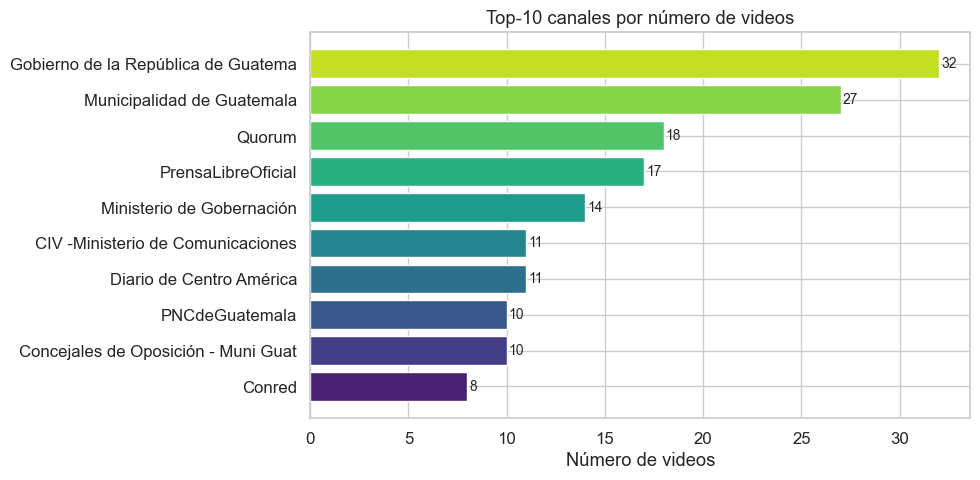

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
top10 = vid_por_canal.head(10).sort_values('n_videos')
ax.barh(top10['canal'].str[:35], top10['n_videos'], color=sns.color_palette('viridis', 10))
ax.set_xlabel('Número de videos')
ax.set_title('Top-10 canales por número de videos')
for i, v in enumerate(top10['n_videos']):
    ax.text(v + 0.1, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.show()

### 3.1.3 Comentarios y autores únicos por video

In [30]:
# Base sobre todos los videos (293), no solo los comentados
conteos_vid = (comments.groupby('video_id')
    .agg(n_comments=('comment_id', 'size'),
          n_autores=('author_channel_id', 'nunique'))
    .reset_index())

comentarios_por_video = (
    videos[['video_id', 'title']]
    .merge(conteos_vid, on='video_id', how='left')
    .fillna(0)
    .rename(columns={'title': 'titulo'})
    .sort_values('n_comments', ascending=False)
    .reset_index(drop=True)
)
comentarios_por_video[['n_comments', 'n_autores']] = \
    comentarios_por_video[['n_comments', 'n_autores']].astype(int)

# Distribución sobre TODOS los videos
print("Distribución de comentarios por video (sobre 293 videos):")
print(f"  Videos sin comentarios: {(comentarios_por_video['n_comments'] == 0).sum()} "
      f"({(comentarios_por_video['n_comments'] == 0).mean():.1%})")
print(f"  Videos con 1 comentario: {(comentarios_por_video['n_comments'] == 1).sum()}")
print(f"  Videos con 2+ comentarios: {(comentarios_por_video['n_comments'] >= 2).sum()}")
print(f"  Mediana: {comentarios_por_video['n_comments'].median():.0f}")
print(f"  Máximo: {comentarios_por_video['n_comments'].max()}")

print("\nTop-10 videos por número de comentarios:")
comentarios_por_video.head(10)

Distribución de comentarios por video (sobre 293 videos):
  Videos sin comentarios: 274 (93.5%)
  Videos con 1 comentario: 4
  Videos con 2+ comentarios: 15
  Mediana: 0
  Máximo: 161

Top-10 videos por número de comentarios:


,video_id,titulo,n_comments,n_autores
0,n8iP75gIpmw,Qué rico come tu diputado,161,128
1,j43HgwYFKfk,La cooptación de Walter Mazariegos en la USAC,50,49
2,6W4u8sGEnGM,Inician los trabajos de recuperación del Puente Belice II.,45,32
3,OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México...,25,18
4,PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,25,19
5,lj983NWyAQY,Plan 2032 Ciudad de Guatemala,25,25
6,yLZS3JiEBg8,Arroz con pollo a la MONOPOLIO,16,16
7,06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer ...,14,13
8,ndAZjHqzzT8,Internet: escoger el menos malo,12,10
9,b_Hkrkl3adA,Bloqueos en Guatemala este 31 de agosto por alza en combustibles afectan rut...,7,7


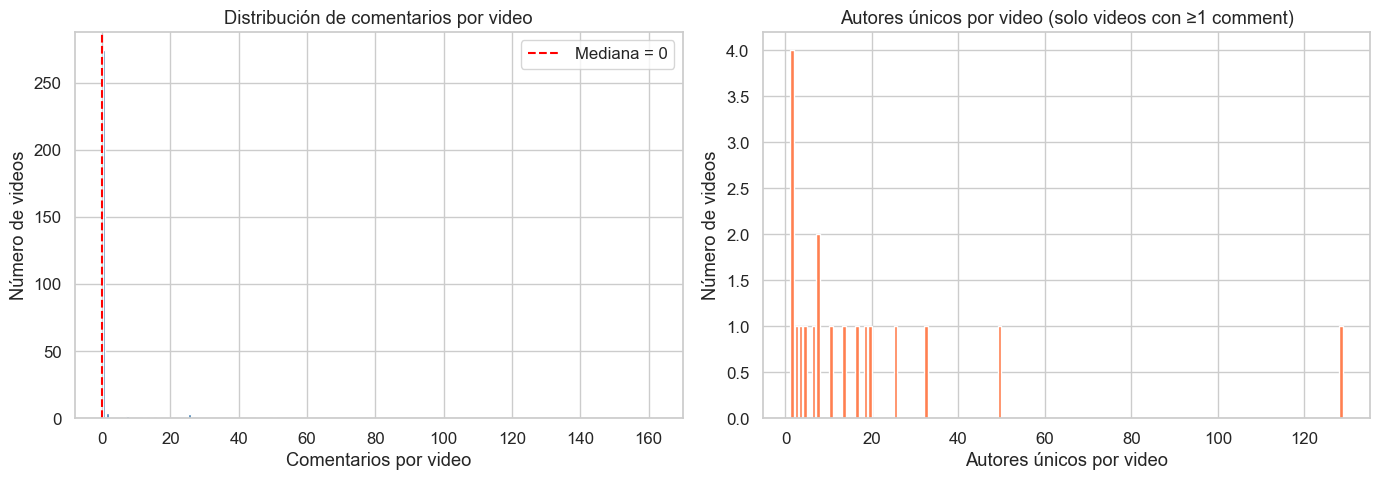

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de comentarios por video
axes[0].hist(comentarios_por_video['n_comments'], bins=range(0, comentarios_por_video['n_comments'].max()+2),
             color='steelblue', edgecolor='white', rwidth=0.8)
axes[0].set_xlabel('Comentarios por video')
axes[0].set_ylabel('Número de videos')
axes[0].set_title('Distribución de comentarios por video')
axes[0].axvline(comentarios_por_video['n_comments'].median(), color='red',
                linestyle='--', label=f'Mediana = {comentarios_por_video["n_comments"].median():.0f}')
axes[0].legend()

# Histograma de autores por video (solo videos con comments)
con_comments = comentarios_por_video[comentarios_por_video['n_comments'] > 0]
axes[1].hist(con_comments['n_autores'], bins=range(1, con_comments['n_autores'].max()+2),
             color='coral', edgecolor='white', rwidth=0.8)
axes[1].set_xlabel('Autores únicos por video')
axes[1].set_ylabel('Número de videos')
axes[1].set_title('Autores únicos por video (solo videos con ≥1 comment)')

plt.tight_layout()
plt.show()

### 3.1.4 Distribución de visualizaciones

Estadísticas de view_count:
count    2.930000e+02
mean     6.043009e+04
std      5.157983e+05
min      2.000000e+00
25%      2.150000e+02
50%      1.175000e+03
75%      7.465000e+03
max      8.190449e+06

Percentil 95: 130,467
Percentil 99: 523,973


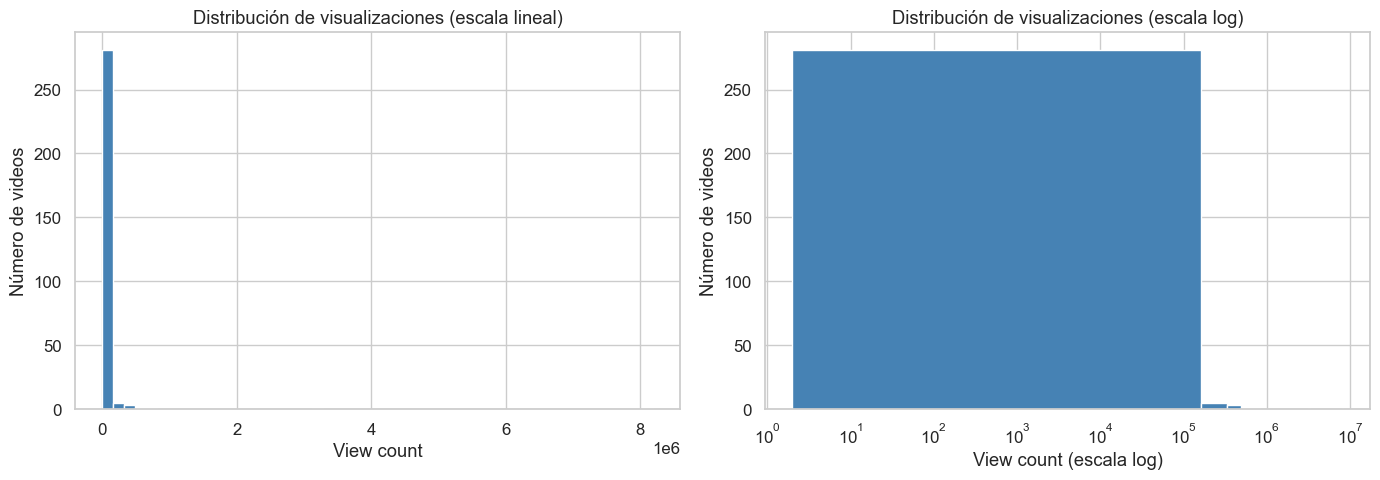

In [32]:
vc = videos['view_count']
print("Estadísticas de view_count:")
print(vc.describe().to_string())
print(f"\nPercentil 95: {vc.quantile(0.95):,.0f}")
print(f"Percentil 99: {vc.quantile(0.99):,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(vc, bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('View count')
axes[0].set_ylabel('Número de videos')
axes[0].set_title('Distribución de visualizaciones (escala lineal)')

axes[1].hist(vc[vc > 0], bins=50, color='steelblue', edgecolor='white')
axes[1].set_xscale('log')
axes[1].set_xlabel('View count (escala log)')
axes[1].set_ylabel('Número de videos')
axes[1].set_title('Distribución de visualizaciones (escala log)')

plt.tight_layout()
plt.show()

### 3.1.5 Distribución de respuestas y "me gusta"

reply_count (comentarios):
count    406.000000
mean       0.125616
std        0.580748
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        7.000000

like_count (comentarios):
count    406.000000
mean       5.726601
std       30.661298
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max      405.000000


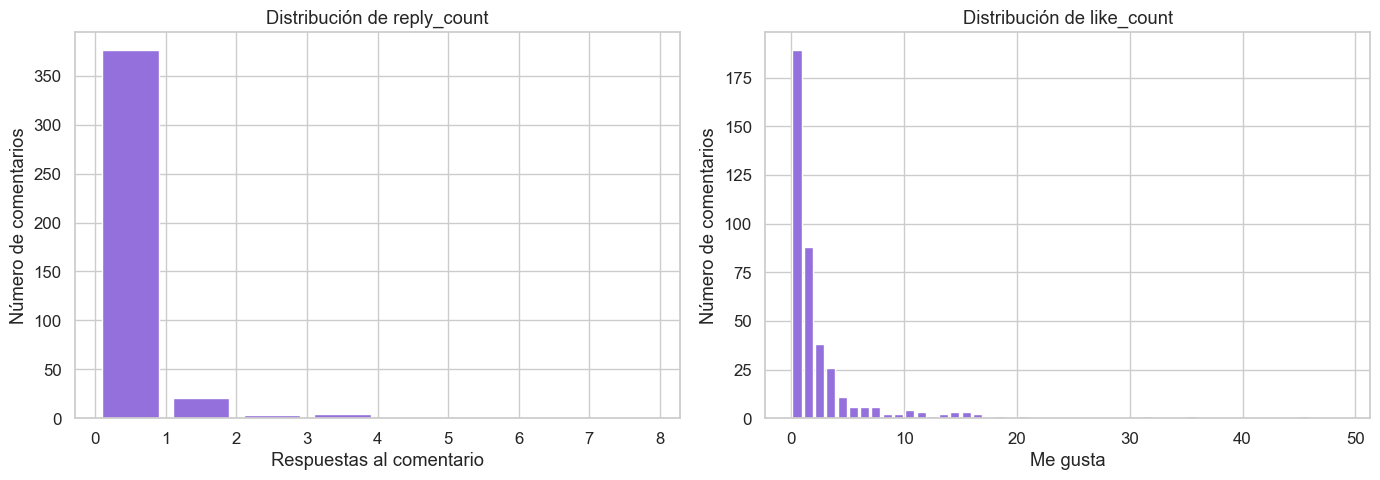

In [33]:
print("reply_count (comentarios):")
print(comments['reply_count'].describe().to_string())
print(f"\nlike_count (comentarios):")
print(comments['like_count'].describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rc = comments['reply_count']
axes[0].hist(rc, bins=range(0, rc.max()+2), color='mediumpurple', edgecolor='white', rwidth=0.8)
axes[0].set_xlabel('Respuestas al comentario')
axes[0].set_ylabel('Número de comentarios')
axes[0].set_title('Distribución de reply_count')

lc = comments['like_count']
axes[1].hist(lc, bins=range(0, min(lc.max()+2, 50)), color='mediumpurple', edgecolor='white', rwidth=0.8)
axes[1].set_xlabel('Me gusta')
axes[1].set_ylabel('Número de comentarios')
axes[1].set_title('Distribución de like_count')

plt.tight_layout()
plt.show()

### 3.1.6 Categorías de YouTube

In [34]:
cat_videos = videos['category'].value_counts().reset_index()
cat_videos.columns = ['Categoría', 'N° videos']
cat_videos['%'] = (cat_videos['N° videos'] / cat_videos['N° videos'].sum() * 100).round(1)

cat_comments = df['category'].value_counts().reset_index()
cat_comments.columns = ['Categoría', 'N° comentarios']
cat_comments['%'] = (cat_comments['N° comentarios'] / cat_comments['N° comentarios'].sum() * 100).round(1)

print("Categorías en videos:")
print(cat_videos.to_string(index=False))
print("\nCategorías en comentarios:")
print(cat_comments.to_string(index=False))

Categorías en videos:
            Categoría  N° videos    %
      News & Politics        138 47.1
       People & Blogs         66 22.5
        Entertainment         48 16.4
            Education         19  6.5
      Travel & Events          8  2.7
 Science & Technology          6  2.0
Nonprofits & Activism          3  1.0
     Film & Animation          2  0.7
               Comedy          1  0.3
               Sports          1  0.3
                Music          1  0.3

Categorías en comentarios:
            Categoría  N° comentarios    %
      News & Politics             335 82.5
        Entertainment              70 17.2
Nonprofits & Activism               1  0.2


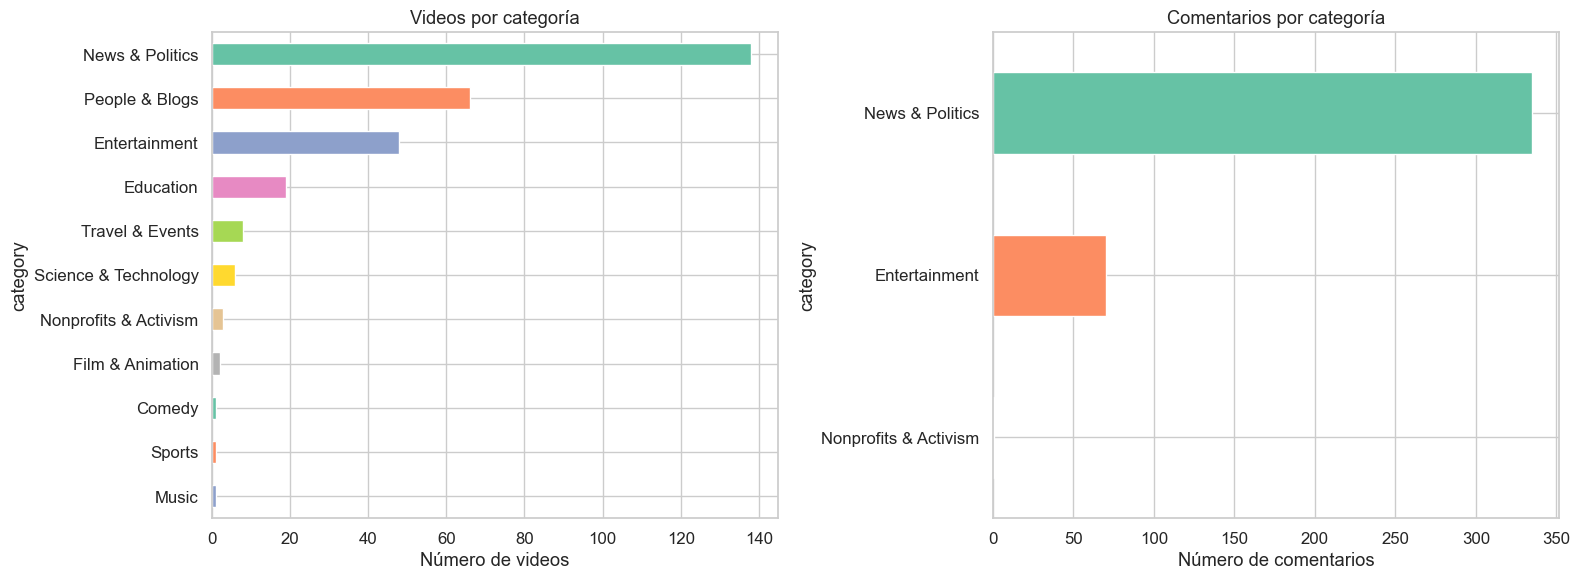

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_v = videos['category'].value_counts()
cat_v.plot.barh(ax=axes[0], color=sns.color_palette('Set2', len(cat_v)))
axes[0].set_xlabel('Número de videos')
axes[0].set_title('Videos por categoría')
axes[0].invert_yaxis()

cat_c = df['category'].value_counts()
cat_c.plot.barh(ax=axes[1], color=sns.color_palette('Set2', len(cat_c)))
axes[1].set_xlabel('Número de comentarios')
axes[1].set_title('Comentarios por categoría')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 3.1.7 Consultas de búsqueda

In [36]:
queries = videos['source_query'].value_counts().reset_index()
queries.columns = ['Consulta', 'N° videos']
queries['%'] = (queries['N° videos'] / queries['N° videos'].sum() * 100).round(1)

print(f"Consultas únicas: {videos['source_query'].nunique()}")
print("\nTop-10 consultas de búsqueda:")
queries.head(10)

Consultas únicas: 21

Top-10 consultas de búsqueda:


,Consulta,N° videos,%
0,Municipalidad de Guatemala,20,6.8
1,Gobierno de Guatemala,18,6.1
2,@GobiernodelaRepublicadeGuatema,18,6.1
3,@GobiernodeGuatemala,17,5.8
4,guatemala noticias,16,5.5
5,Ministerio de Comunicaciones Guatemala,16,5.5
6,@MunicipalidaddeGuatemala-1551,16,5.5
7,Gobierno de la República de Guatemala,15,5.1
8,PMT Guatemala,15,5.1
9,Conred Guatemala,15,5.1


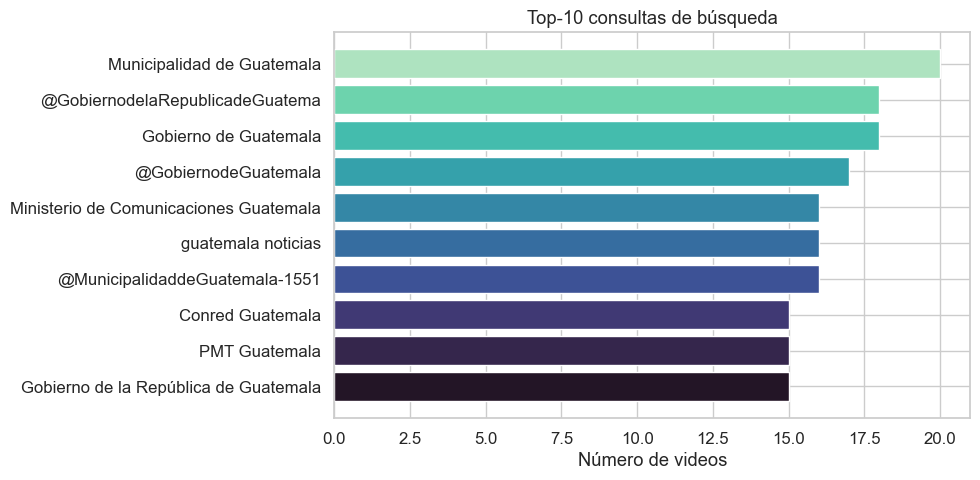

In [37]:
fig, ax = plt.subplots(figsize=(10, 5))
top_q = queries.head(10).sort_values('N° videos')
ax.barh(top_q['Consulta'].str[:40], top_q['N° videos'],
        color=sns.color_palette('mako', 10))
ax.set_xlabel('Número de videos')
ax.set_title('Top-10 consultas de búsqueda')
plt.tight_layout()
plt.show()

### 3.1.8 Hashtags frecuentes

Total hashtags extraídos: 1
Hashtags únicos: 1

Top-15 hashtags:
   Hashtag  Frecuencia
ineptobran           1


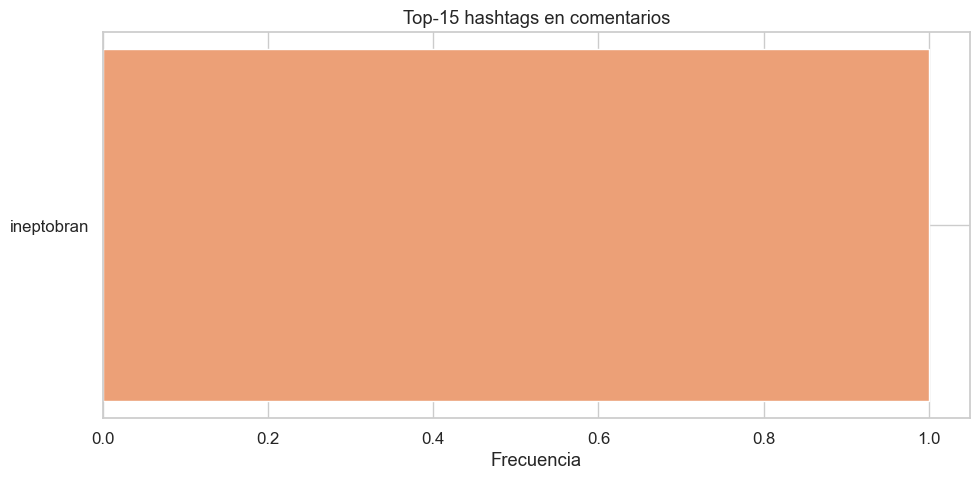

In [38]:
all_hashtags = []
for text in comments['texto_original'].dropna():
    all_hashtags.extend([h.lower() for h in re.findall(r'#(\w+)', str(text))])

ht_counts = Counter(all_hashtags)
print(f"Total hashtags extraídos: {len(all_hashtags)}")
print(f"Hashtags únicos: {len(ht_counts)}")

if ht_counts:
    top_ht = pd.DataFrame(ht_counts.most_common(15), columns=['Hashtag', 'Frecuencia'])
    print("\nTop-15 hashtags:")
    print(top_ht.to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 5))
    top_ht_sorted = top_ht.sort_values('Frecuencia')
    ax.barh(top_ht_sorted['Hashtag'], top_ht_sorted['Frecuencia'],
            color=sns.color_palette('flare', 15))
    ax.set_xlabel('Frecuencia')
    ax.set_title('Top-15 hashtags en comentarios')
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron hashtags en los comentarios.")

### 3.1.9 Palabras y bigramas frecuentes

Tokens totales (>2 chars): 4757
Vocabulario único: 2068


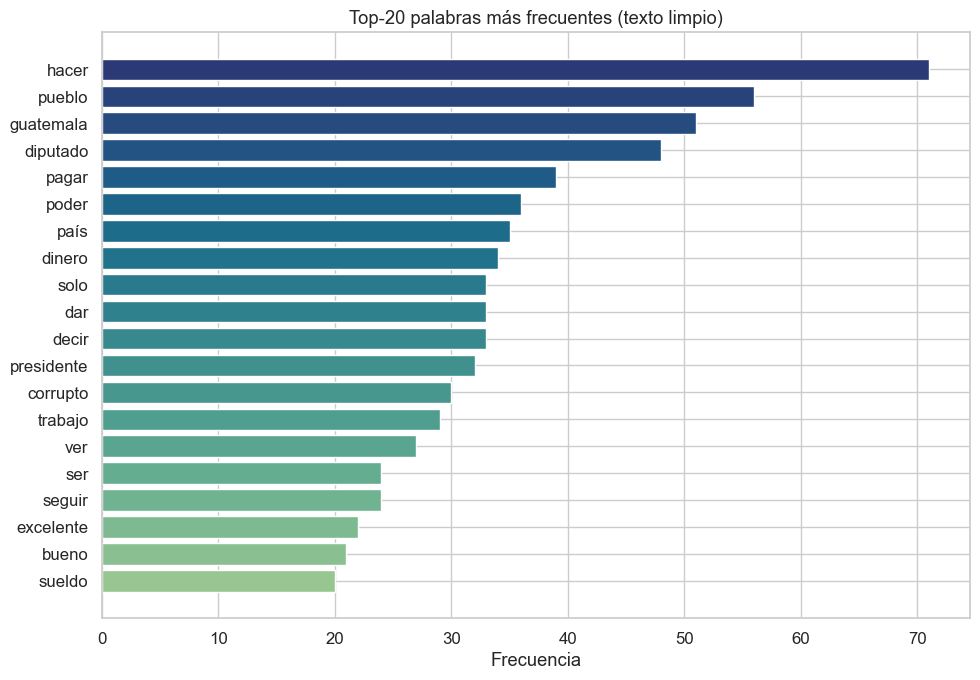

In [39]:
all_words = []
for text in comments['texto_limpio'].dropna():
    words = str(text).split()
    all_words.extend([w for w in words if len(w) > 2])

word_counts = Counter(all_words)
top_words = pd.DataFrame(word_counts.most_common(20), columns=['Palabra', 'Frecuencia'])

print(f"Tokens totales (>2 chars): {len(all_words)}")
print(f"Vocabulario único: {len(word_counts)}")

fig, ax = plt.subplots(figsize=(10, 7))
top_w = top_words.sort_values('Frecuencia')
ax.barh(top_w['Palabra'], top_w['Frecuencia'], color=sns.color_palette('crest', 20))
ax.set_xlabel('Frecuencia')
ax.set_title('Top-20 palabras más frecuentes (texto limpio)')
plt.tight_layout()
plt.show()

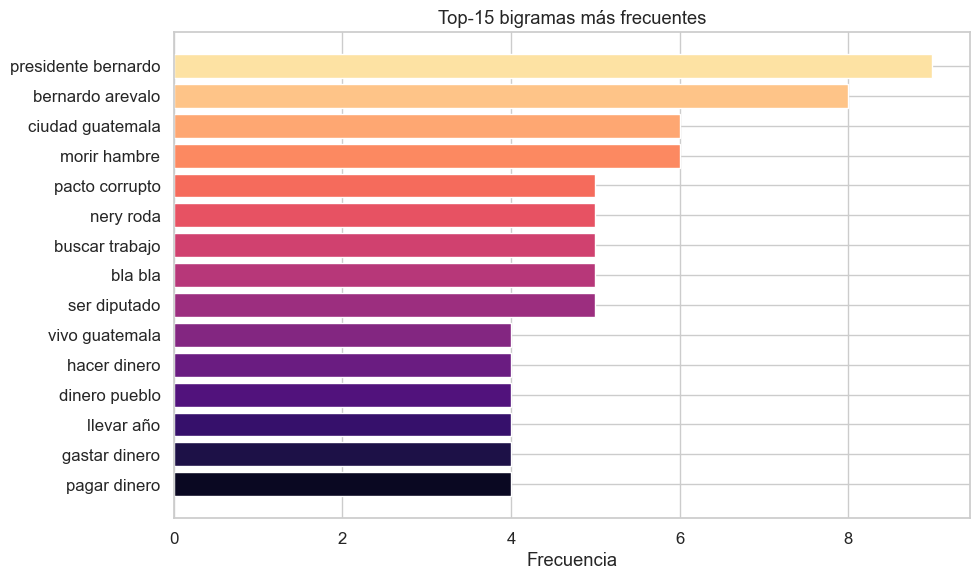

In [40]:
# Bigramas
all_bigrams = []
for text in comments['texto_limpio'].dropna():
    tokens = [w for w in str(text).split() if len(w) > 2]
    all_bigrams.extend(list(nltk.bigrams(tokens))) if len(tokens) >= 2 else None

bigram_counts = Counter(all_bigrams)
top_bg = pd.DataFrame(bigram_counts.most_common(15),
                       columns=['Bigrama', 'Frecuencia'])
top_bg['Bigrama'] = top_bg['Bigrama'].apply(lambda x: f"{x[0]} {x[1]}")

fig, ax = plt.subplots(figsize=(10, 6))
top_bg_sorted = top_bg.sort_values('Frecuencia')
ax.barh(top_bg_sorted['Bigrama'], top_bg_sorted['Frecuencia'],
        color=sns.color_palette('magma', 15))
ax.set_xlabel('Frecuencia')
ax.set_title('Top-15 bigramas más frecuentes')
plt.tight_layout()
plt.show()

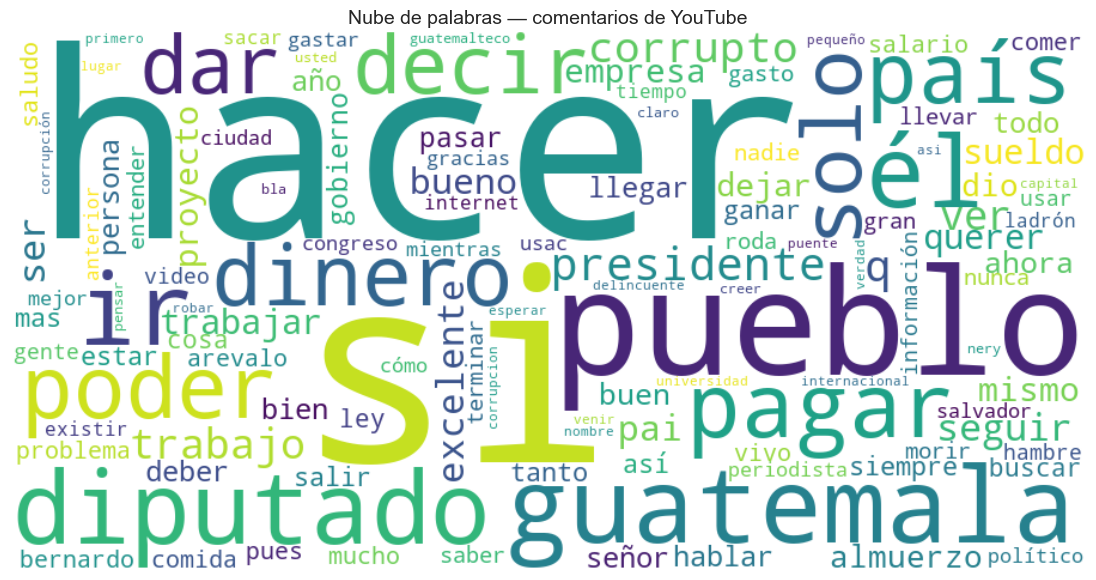

In [41]:
# Nube de palabras
texto_todo = ' '.join(comments['texto_limpio'].dropna().astype(str))

wc = WordCloud(width=900, height=450, background_color='white',
               max_words=120, colormap='viridis',
               collocations=False, min_font_size=10)
wc.generate(texto_todo)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Nube de palabras — comentarios de YouTube', fontsize=14)
plt.tight_layout()
plt.show()

## 3.2 Concentración de la participación

Se evalúa qué proporción de los comentarios se concentra en los videos y canales más activos.

Concentración de comentarios:
  Top-10% videos (30): 100.0% de los comentarios
  Top-10% canales (10): 100.0% de los comentarios
  Top-20% videos (59): 100.0% de los comentarios
  Top-20% canales (20): 100.0% de los comentarios
  Top-30% videos (88): 100.0% de los comentarios
  Top-30% canales (30): 100.0% de los comentarios


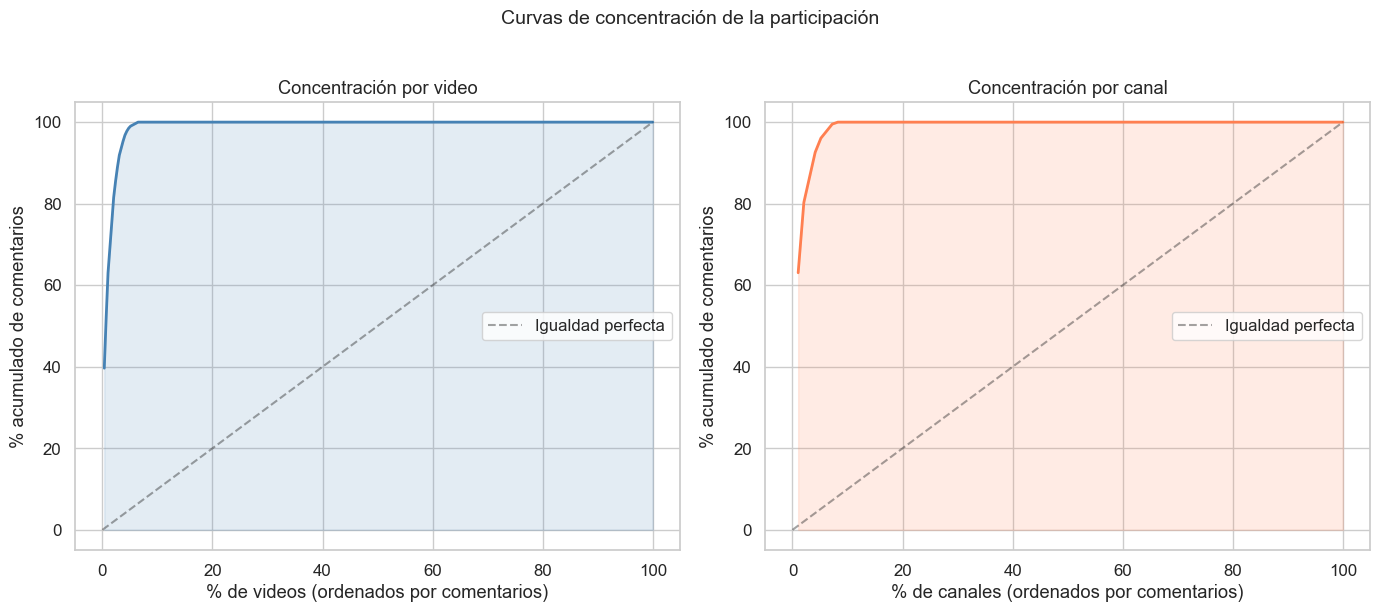

In [42]:
# Comentarios por video (incluyendo videos con 0)
all_vid = videos[['video_id']].copy()
counts_vid = comments.groupby('video_id').size().reset_index(name='n_comments')
all_vid = all_vid.merge(counts_vid, on='video_id', how='left').fillna(0)
all_vid = all_vid.sort_values('n_comments', ascending=False).reset_index(drop=True)
all_vid['cum_comments'] = all_vid['n_comments'].cumsum()
all_vid['cum_pct_comments'] = all_vid['cum_comments'] / all_vid['n_comments'].sum() * 100
all_vid['pct_videos'] = np.arange(1, len(all_vid)+1) / len(all_vid) * 100

# Comentarios por canal
counts_ch = comments.groupby('channel_id').size().reset_index(name='n_comments')
all_ch = videos[['channel_id']].drop_duplicates().merge(counts_ch, on='channel_id', how='left').fillna(0)
all_ch = all_ch.sort_values('n_comments', ascending=False).reset_index(drop=True)
all_ch['cum_comments'] = all_ch['n_comments'].cumsum()
all_ch['cum_pct_comments'] = all_ch['cum_comments'] / all_ch['n_comments'].sum() * 100
all_ch['pct_canales'] = np.arange(1, len(all_ch)+1) / len(all_ch) * 100

print("Concentración de comentarios:")
for pct in [10, 20, 30]:
    n_vid = int(np.ceil(pct / 100 * len(all_vid)))
    n_ch = int(np.ceil(pct / 100 * len(all_ch)))
    print(f"  Top-{pct}% videos ({n_vid}): {all_vid.iloc[n_vid-1]['cum_pct_comments']:.1f}% de los comentarios")
    print(f"  Top-{pct}% canales ({n_ch}): {all_ch.iloc[n_ch-1]['cum_pct_comments']:.1f}% de los comentarios")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Videos
axes[0].plot(all_vid['pct_videos'], all_vid['cum_pct_comments'], color='steelblue', linewidth=2)
axes[0].plot([0, 100], [0, 100], 'k--', alpha=0.4, label='Igualdad perfecta')
axes[0].fill_between(all_vid['pct_videos'], all_vid['cum_pct_comments'],
                     alpha=0.15, color='steelblue')
axes[0].set_xlabel('% de videos (ordenados por comentarios)')
axes[0].set_ylabel('% acumulado de comentarios')
axes[0].set_title('Concentración por video')
axes[0].legend()

# Canales
axes[1].plot(all_ch['pct_canales'], all_ch['cum_pct_comments'], color='coral', linewidth=2)
axes[1].plot([0, 100], [0, 100], 'k--', alpha=0.4, label='Igualdad perfecta')
axes[1].fill_between(all_ch['pct_canales'], all_ch['cum_pct_comments'],
                     alpha=0.15, color='coral')
axes[1].set_xlabel('% de canales (ordenados por comentarios)')
axes[1].set_ylabel('% acumulado de comentarios')
axes[1].set_title('Concentración por canal')
axes[1].legend()

plt.suptitle('Curvas de concentración de la participación', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Interpretación (3.2).** La participación está **altamente concentrada**: dado que más del 90% de los videos no tiene comentarios capturados, el 10% de los videos más activos concentra el 100% de los comentarios. A nivel de canales, unos pocos (Quorum y cuentas gubernamentales) explican la mayor parte de la participación. Esta concentración extrema refleja tanto la distribución real de actividad como la cobertura sesgada del muestreo (ver Q6).

## 3.3 Popularidad vs participación

Se evalúa la relación entre las **visualizaciones** del video (métrica de *visibilidad* o alcance) y el **número de comentarios** que recibió (métrica de *participación*).

**Hallazgo principal:** entre los 19 videos que sí tienen comentarios recolectados, existe una correlación de **Spearman ρ = 0.811** (p < 0.001), lo que indica una asociación positiva fuerte: los videos más vistos tienden a concentrar más comentarios.

**Limitaciones de ambos conteos:**
- *Solo 19 de 293 videos tienen comentarios*: la correlación se calcula únicamente sobre ese subconjunto, por lo que no describe la relación en el resto de contenidos donde la participación no fue recolectada.
- `view_count` incluye reproducciones automáticas, vistas de bots o tráfico no orgánico, por lo que puede sobreestimar la "popularidad real".
- La correlación entre *medios* no implica causalidad: un video puede ser visto por su tema sin generar comentarios, o generar muchas conversaciones aunque tenga pocas vistas.
- `n_comments` solo cuenta comentarios *principales* capturados (no respuestas), lo que subestima la participación total.

Spearman (views vs comments, videos con ≥1 comment): ρ = 0.811, p = 0.0000
Videos con comentarios: 19 de 293


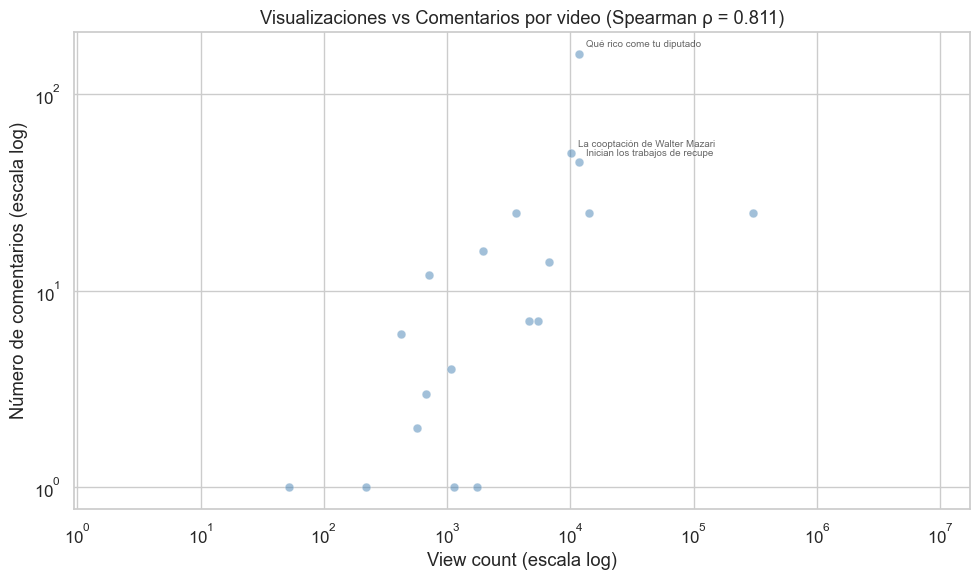

In [43]:
# Preparar datos: videos con su conteo de comentarios
vid_stats = videos[['video_id', 'title', 'channel_name', 'category', 'view_count']].copy()
vid_stats = vid_stats.merge(
    comments.groupby('video_id').agg(
        n_comments=('comment_id', 'size'),
        n_autores=('author_channel_id', 'nunique'),
        total_likes=('like_count', 'sum')
    ).reset_index(),
    on='video_id', how='left'
)
vid_stats['n_comments'] = vid_stats['n_comments'].fillna(0).astype(int)
vid_stats['n_autores'] = vid_stats['n_autores'].fillna(0).astype(int)
vid_stats['total_likes'] = vid_stats['total_likes'].fillna(0).astype(int)

# Spearman solo para videos con al menos 1 comentario
con_comments = vid_stats[vid_stats['n_comments'] > 0]
rho, pval = spearmanr(con_comments['view_count'], con_comments['n_comments'])
print(f"Spearman (views vs comments, videos con ≥1 comment): ρ = {rho:.3f}, p = {pval:.4f}")
print(f"Videos con comentarios: {len(con_comments)} de {len(vid_stats)}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(vid_stats['view_count'], vid_stats['n_comments'],
           alpha=0.5, s=40, color='steelblue', edgecolors='white', linewidth=0.5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('View count (escala log)')
ax.set_ylabel('Número de comentarios (escala log)')
ax.set_title(f'Visualizaciones vs Comentarios por video (Spearman ρ = {rho:.3f})')

# Anotar outliers
top3_views = vid_stats.nlargest(3, 'view_count')
top3_comments = vid_stats.nlargest(3, 'n_comments')
for _, row in pd.concat([top3_views, top3_comments]).drop_duplicates('video_id').iterrows():
    ax.annotate(row['title'][:30], (row['view_count'], row['n_comments']),
                fontsize=7, alpha=0.7, xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

## 3.4 Visualizaciones

Las visualizaciones principales se distribuyeron en las subsecciones de 3.1 y 3.3. A continuación se agregan gráficos complementarios de concentración por categoría.

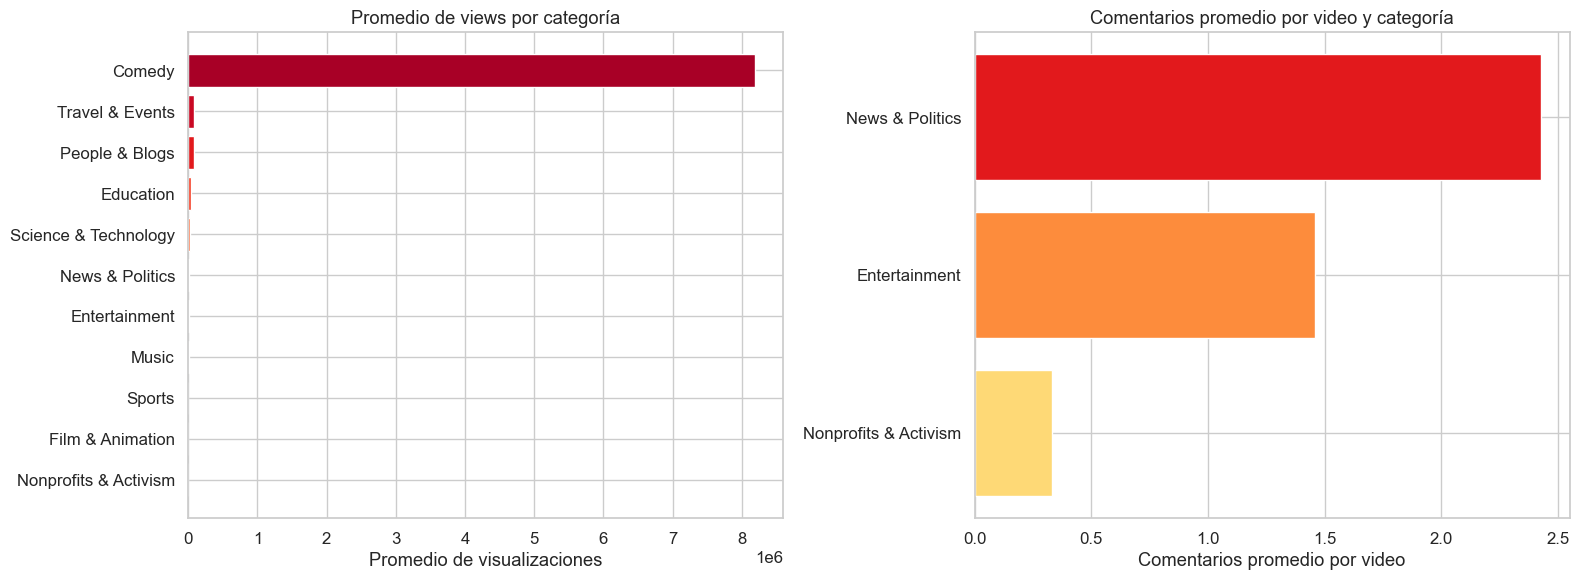

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Promedio de views por categoría
views_cat = videos.groupby('category')['view_count'].agg(['mean', 'median', 'count']).reset_index()
views_cat = views_cat.sort_values('mean', ascending=True)
axes[0].barh(views_cat['category'], views_cat['mean'], color=sns.color_palette('YlOrRd', len(views_cat)))
axes[0].set_xlabel('Promedio de visualizaciones')
axes[0].set_title('Promedio de views por categoría')

# Promedio de comments por categoría
comments_cat = df.groupby('category').size().reset_index(name='n_comments')
vids_cat = videos['category'].value_counts().reset_index()
vids_cat.columns = ['category', 'n_videos']
cat_merge = comments_cat.merge(vids_cat, on='category')
cat_merge['comments_per_video'] = cat_merge['n_comments'] / cat_merge['n_videos']
cat_merge = cat_merge.sort_values('comments_per_video', ascending=True)
axes[1].barh(cat_merge['category'], cat_merge['comments_per_video'],
             color=sns.color_palette('YlOrRd', len(cat_merge)))
axes[1].set_xlabel('Comentarios promedio por video')
axes[1].set_title('Comentarios promedio por video y categoría')

plt.tight_layout()
plt.show()

## 3.5 Preguntas del enunciado

### Q1 — ¿Qué videos y canales concentran la mayor participación observada?

In [45]:
print("='="*25)
print("TOP-10 VIDEOS POR NÚMERO DE COMENTARIOS")
print("='="*25)
top_vid = vid_stats.nlargest(10, 'n_comments')[['title', 'channel_name', 'category',
                                                'view_count', 'n_comments', 'total_likes']]
top_vid = top_vid.reset_index(drop=True)
top_vid.index += 1
print(top_vid.to_string())

print(f"\n{'='*50}")
print("TOP-10 CANALES POR NÚMERO DE COMENTARIOS")
print(f"\n{'='*50}")
top_ch = (df.groupby('channel_id_comment')
    .agg(n_comments=('comment_id', 'size'),
          n_autores=('author_channel_id', 'nunique'),
          canal=('channel_name_comment', 'first'))
    .sort_values('n_comments', ascending=False)
    .head(10).reset_index())
top_ch.index += 1
print(top_ch.to_string())

='=='=='=='=='=='=='=='=='=='=='=='=='=='=='=='=='=='=='=='=='=='=='=='=='=
TOP-10 VIDEOS POR NÚMERO DE COMENTARIOS
='=='=='=='=='=='=='=='=='=='=='=='=='=='=='=='=='=='=='=='=='=='=='=='=='=
                                                                                                title                           channel_name         category  view_count  n_comments  total_likes
1                                                                           Qué rico come tu diputado                                 Quorum  News & Politics       11775         161          358
2                                                       La cooptación de Walter Mazariegos en la USAC                                 Quorum  News & Politics       10156          50           91
3                                          Inician los trabajos de recuperación del Puente Belice II.  Gobierno de la República de Guatemala    Entertainment       11670          45           90
4   EE.UU. envía a mexicanos

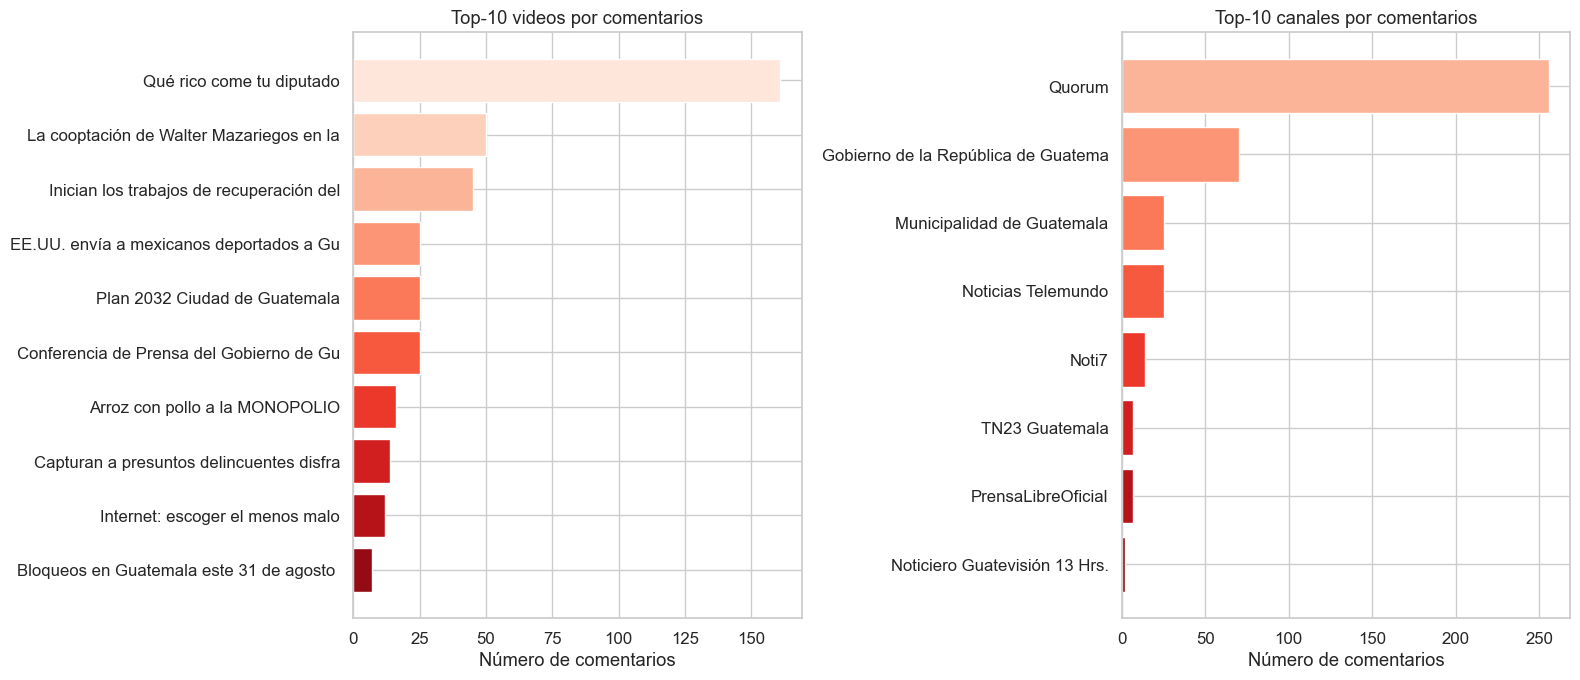

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

tv = vid_stats.nlargest(10, 'n_comments').sort_values('n_comments')
axes[0].barh(tv['title'].str[:40], tv['n_comments'], color=sns.color_palette('Reds_r', 10))
axes[0].set_xlabel('Número de comentarios')
axes[0].set_title('Top-10 videos por comentarios')

tch = top_ch.sort_values('n_comments')
axes[1].barh(tch['canal'].str[:35], tch['n_comments'], color=sns.color_palette('Reds_r', 10))
axes[1].set_xlabel('Número de comentarios')
axes[1].set_title('Top-10 canales por comentarios')

plt.tight_layout()
plt.show()

**Interpretación (Q1).** La mayor participación se concentra en **Quorum**, cuyos videos acumulan 256 comentarios de 214 autores distintos — más de la mitad de toda la participación (256/406 = 63%). El video *"Qué rico come tu diputado"* (161 comentarios) domina la participación individual. Le siguen canales gubernamentales (Gobierno de la República de Guatemala: 70) y de medios (Noticias Telemundo: 25, Municipalidad de Guatemala: 25).

### Q2 — ¿Existen audiencias compartidas entre videos, canales o temas?

In [47]:
# Autores que comentaron en más de 1 video
author_vid_count = comments.groupby('author_channel_id')['video_id'].nunique().reset_index()
author_vid_count.columns = ['author_channel_id', 'n_videos_commented']

n_multi = (author_vid_count['n_videos_commented'] > 1).sum()
n_total = len(author_vid_count)
pct_multi = n_multi / n_total * 100

print(f"Autores únicos: {n_total}")
print(f"Autores que comentaron en >1 video: {n_multi} ({pct_multi:.1f}%)")
print(f"Autores que comentaron en >2 videos: {(author_vid_count['n_videos_commented'] > 2).sum()}")

print("\nDistribución de videos comentados por autor:")
print(author_vid_count['n_videos_commented'].value_counts().sort_index().to_string())

# Videos que recibieron comentarios de autores que también comentaron en otros videos
multi_authors = set(author_vid_count[author_vid_count['n_videos_commented'] > 1]['author_channel_id'])
vids_with_multi = comments[comments['author_channel_id'].isin(multi_authors)]['video_id'].nunique()
print(f"\nVideos que recibieron al menos 1 comentario de un autor multi-video: {vids_with_multi} de {len(videos)}")

Autores únicos: 332
Autores que comentaron en >1 video: 9 (2.7%)
Autores que comentaron en >2 videos: 2

Distribución de videos comentados por autor:
n_videos_commented
1    323
2      7
3      2

Videos que recibieron al menos 1 comentario de un autor multi-video: 10 de 293


In [48]:
# Autores multi-video: quiénes son
top_multi = author_vid_count.nlargest(10, 'n_videos_commented')
top_multi = top_multi.merge(
    comments.groupby('author_channel_id').agg(
        author_name=('author_name', 'first'),
        n_comments=('comment_id', 'size')
    ).reset_index(),
    on='author_channel_id'
)
print("Top-10 autores más activos (por videos distintos comentados):")
print(top_multi[['author_name', 'n_videos_commented', 'n_comments']].to_string(index=False))


Top-10 autores más activos (por videos distintos comentados):
         author_name  n_videos_commented  n_comments
      @inge_vergueta                   3           3
       @hashojea7348                   3           4
 @virgiliogarcia3039                   2           3
     @Alejandro00710                   2           2
  @MarcosCarillo-b1r                   2           2
@franciscoflores3120                   2           2
   @moisesvaldez4043                   2           2
        @Jel.Awesh.M                   2           3
        @josegil3813                   2           2
   @JorgeMunoz-gd9et                   1           1


**Interpretación (Q2).** Las audiencias compartidas son **escasas**: solo 9 de 332 autores (2.7%) comentaron en más de un video, y solo 2 lo hicieron en 3. Esto significa que la red bipartita autor-video está fuertemente fragmentada: la mayoría de los autores participa en un único video, por lo que la "audiencia compartida" entre contenidos se limita a unos pocos autores puente.

### Q3 — ¿Qué autores funcionan como puentes entre contenidos que de otra forma permanecerían separados?

Se construye un **grafo proyectado** donde los nodos son videos y hay una arista entre dos videos si comparten al menos un autor. La **betweenness centrality** identifica los videos que conectan comunidades distintas.

In [49]:
# Grafo bipartito: autor -> video
bipartite_edges = comments[['author_channel_id', 'video_id']].drop_duplicates().values.tolist()

# Proyección sobre videos: arista si comparten al menos 1 autor
author_to_videos = {}
for author, video in bipartite_edges:
    author_to_videos.setdefault(author, set()).add(video)

G_video = nx.Graph()
all_videos_in_comments = set(comments['video_id'].unique())
G_video.add_nodes_from(all_videos_in_comments)

for author, vids in author_to_videos.items():
    vids_list = list(vids)
    for i in range(len(vids_list)):
        for j in range(i+1, len(vids_list)):
            if G_video.has_edge(vids_list[i], vids_list[j]):
                G_video[vids_list[i]][vids_list[j]]['weight'] += 1
            else:
                G_video.add_edge(vids_list[i], vids_list[j], weight=1)

print(f"Nodos (videos con comments): {G_video.number_of_nodes()}")
print(f"Aristas (comparten autor): {G_video.number_of_edges()}")
print(f"Componentes conectados: {nx.number_connected_components(G_video)}")

Nodos (videos con comments): 19
Aristas (comparten autor): 11
Componentes conectados: 10


In [50]:
# Betweenness centrality
bc = nx.betweenness_centrality(G_video, weight='weight')
bc_sorted = sorted(bc.items(), key=lambda x: x[1], reverse=True)

print("Top-10 videos con mayor betweenness centrality (puentes entre comunidades):")
for vid, centr in bc_sorted[:10]:
    title = videos.loc[videos['video_id'] == vid, 'title'].values
    title = title[0][:60] if len(title) > 0 else 'N/A'
    n_nei = G_video.degree(vid)
    print(f"  {centr:.4f}  ({n_nei:2d} vecinos)  {title}")

Top-10 videos con mayor betweenness centrality (puentes entre comunidades):
  0.1503  ( 4 vecinos)  Qué rico come tu diputado
  0.1242  ( 4 vecinos)  Internet: escoger el menos malo
  0.0915  ( 2 vecinos)  Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt
  0.0523  ( 2 vecinos)  Inician los trabajos de recuperación del Puente Belice II.
  0.0523  ( 3 vecinos)  La cooptación de Walter Mazariegos en la USAC
  0.0261  ( 2 vecinos)  Caminar en una ciudad hecha para carros
  0.0000  ( 0 vecinos)  Noticiero en Directo 1 pm, 28 de Agosto de 2026
  0.0000  ( 2 vecinos)  Arroz con pollo a la MONOPOLIO
  0.0000  ( 0 vecinos)  Edén por Salud: empleo inclusivo para personas con discapaci
  0.0000  ( 0 vecinos)  EE.UU. envía a mexicanos deportados a Guatemala antes de su 


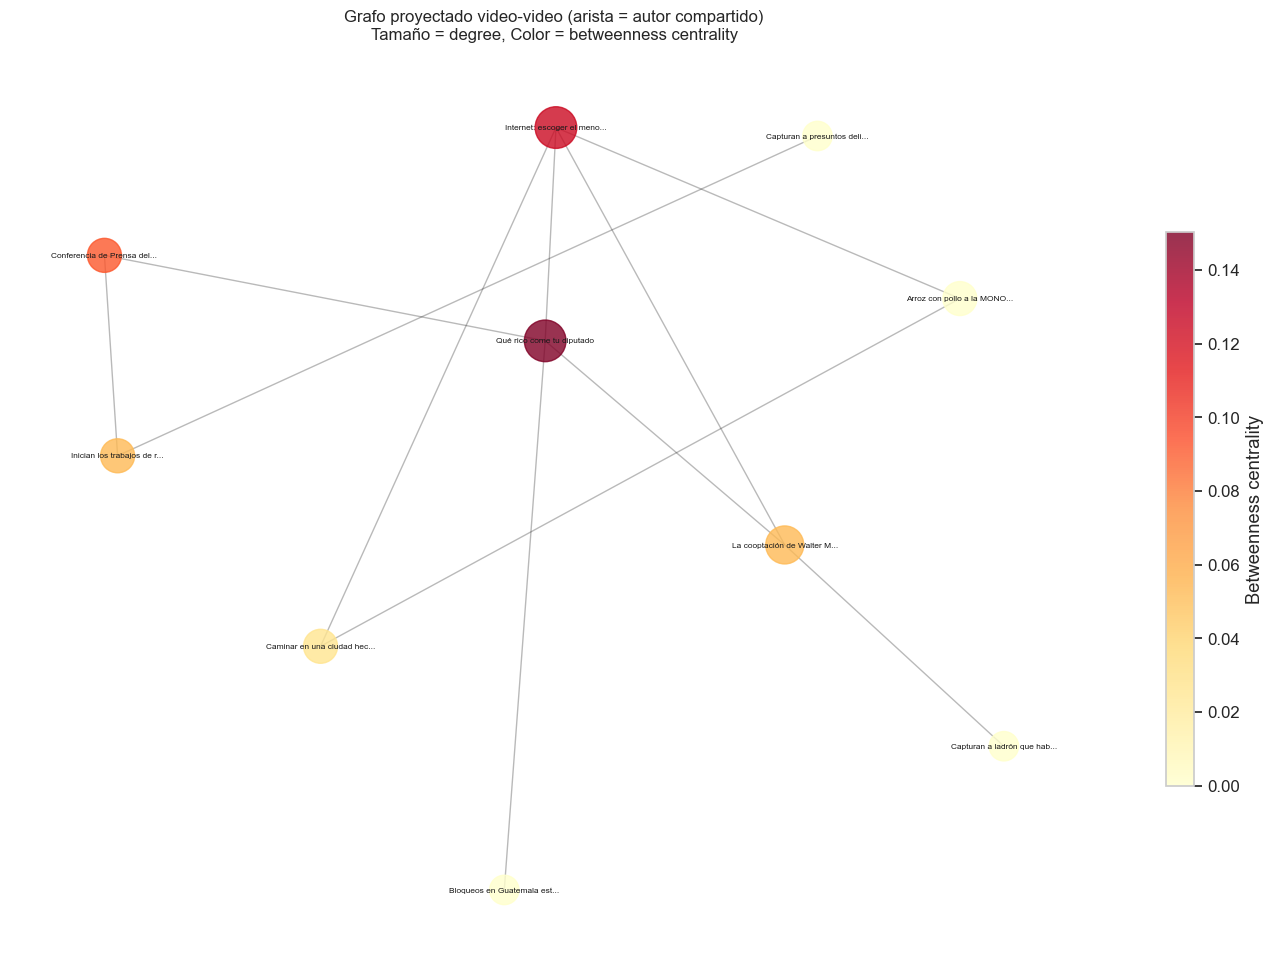

In [51]:
# Visualización del grafo (solo componentes con más nodos)
components = list(nx.connected_components(G_video))
components.sort(key=len, reverse=True)

if components and len(components[0]) >= 3:
    largest = components[0]
    subG = G_video.subgraph(largest).copy()

    # Agregar labels legibles
    labels = {}
    for n in subG.nodes():
        t = videos.loc[videos['video_id'] == n, 'title'].values
        labels[n] = (t[0][:25] + '...') if len(t) > 0 and len(t[0]) > 25 else (t[0] if len(t) > 0 else n[:10])

    # Tamaño proporcional a degree
    degrees = dict(subG.degree())
    node_sizes = [300 + 150 * degrees[n] for n in subG.nodes()]

    # Color por betweenness
    bc_vals = [bc.get(n, 0) for n in subG.nodes()]

    fig, ax = plt.subplots(figsize=(14, 10))
    pos = nx.spring_layout(subG, k=2, seed=42, iterations=50)
    nx.draw_networkx_edges(subG, pos, alpha=0.3, ax=ax)
    nodes = nx.draw_networkx_nodes(subG, pos, node_size=node_sizes,
                                   node_color=bc_vals, cmap=plt.cm.YlOrRd,
                                   alpha=0.8, ax=ax)
    nx.draw_networkx_labels(subG, pos, labels, font_size=6, ax=ax)
    plt.colorbar(nodes, ax=ax, label='Betweenness centrality', shrink=0.6)
    ax.set_title('Grafo proyectado video-video (arista = autor compartido)\n'
                 'Tamaño = degree, Color = betweenness centrality', fontsize=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No hay componente lo suficientemente grande para graficar.")

**Interpretación (Q3).** Los videos con mayor betweenness centrality son los que conectan comunidades dispares: *"Qué rico come tu diputado"* (bc=0.15, 4 vecinos) y *"Internet: escoger el menos malo"* (bc=0.12) son los principales puentes, al compartir autores con varios otros videos. Los autores que comentan en varios videos (solo 9 de 332, 2.7%) son quienes crean estos enlaces entre contenidos que de otro modo estarían aislados.

### Q4 — ¿Qué temas y sentimientos caracterizan a las principales comunidades de participación?

Se detectan comunidades en el grafo proyectado usando el algoritmo de Louvain y se analizan los temas y sentimiento de cada una.

In [52]:
# Detectar comunidades con Louvain
communities = louvain_communities(G_video, seed=42)
communities.sort(key=len, reverse=True)

print(f"Comunidades detectadas: {len(communities)}")
for i, comm in enumerate(communities):
    print(f"  Comunidad {i+1}: {len(comm)} videos")

Comunidades detectadas: 12
  Comunidad 1: 4 videos
  Comunidad 2: 3 videos
  Comunidad 3: 3 videos
  Comunidad 4: 1 videos
  Comunidad 5: 1 videos
  Comunidad 6: 1 videos
  Comunidad 7: 1 videos
  Comunidad 8: 1 videos
  Comunidad 9: 1 videos
  Comunidad 10: 1 videos
  Comunidad 11: 1 videos
  Comunidad 12: 1 videos


In [53]:
# Diccionario léxico simple de sentimiento para español
POSITIVE_WORDS = {
    'bien', 'bueno', 'buena', 'buenos', 'buenas', 'gracias', 'excelente',
    'perfecto', 'genial', 'increíble', 'lindo', 'bonito', 'hermoso',
    'amor', 'feliz', 'felicidades', 'apoyo', 'correcto', 'verdad',
    'viva', 'bravo', 'sigue', 'fuerza', 'aplauso', 'aplausos', 'gustar',
    'mejor', 'super', 'favorito', 'recomendar', 'aprender', 'victoria'
}
NEGATIVE_WORDS = {
    'malo', 'mala', 'malos', 'corrupto', 'corruptos', 'ladrón', 'ladrones',
    'robar', 'robo', 'muerte', 'violencia', 'miedo', 'odio', 'basura',
    'terrible', 'horrible', 'asco', 'vergüenza', 'culpa', 'mentira',
    'mentiroso', 'criminal', 'crimen', 'injusto', 'injusticia', 'abuso',
    'mafioso', 'narco', 'pobreza', 'hambre', 'destruir', 'destrucción'
}

def sentimiento_simple(texto):
    """Retorna score de sentimiento: positivo (>0), neutro (0), negativo (<0)"""
    palabras = set(str(texto).lower().split())
    pos = len(palabras & POSITIVE_WORDS)
    neg = len(palabras & NEGATIVE_WORDS)
    total = pos + neg
    if total == 0:
        return 0.0
    return (pos - neg) / total

# Analizar cada comunidad
print(f"{'Comunidad':<12} {'Videos':>6} {'Autores':>8} {'Sent.':>7}  Top-5 palabras")
print("-" * 80)

for i, comm in enumerate(communities[:8]):
    vids_in_comm = list(comm)
    comms_in_comm = comments[comments['video_id'].isin(vids_in_comm)]
    
    n_vids = len(vids_in_comm)
    n_authors = comms_in_comm['author_channel_id'].nunique()
    
    # Palabras frecuentes
    words = []
    for t in comms_in_comm['texto_limpio'].dropna():
        words.extend([w for w in str(t).split() if len(w) > 2])
    top5 = [w for w, _ in Counter(words).most_common(5)]
    
    # Sentimiento promedio
    sent = comms_in_comm['texto_limpio'].apply(sentimiento_simple).mean()
    
    print(f"  {i+1:<10} {n_vids:>6} {n_authors:>8} {sent:>+7.2f}  {', '.join(top5)}")

Comunidad    Videos  Autores   Sent.  Top-5 palabras
--------------------------------------------------------------------------------
  1               4      187   -0.03  pueblo, diputado, hacer, pagar, dinero
  2               3       29   +0.33  excelente, hacer, empresa, poder, solo
  3               3       62   +0.17  presidente, hacer, guatemala, país, año
  4               1        2   +0.00  persona, encargado, ecosistema, ayude, problema
  5               1        1   +0.00  
  6               1       18   +0.08  you, país, usar, entrar, deportar
  7               1        4   +0.50  juego, excelente, iniciativa, ver, deporte
  8               1        1   +0.00  wooow


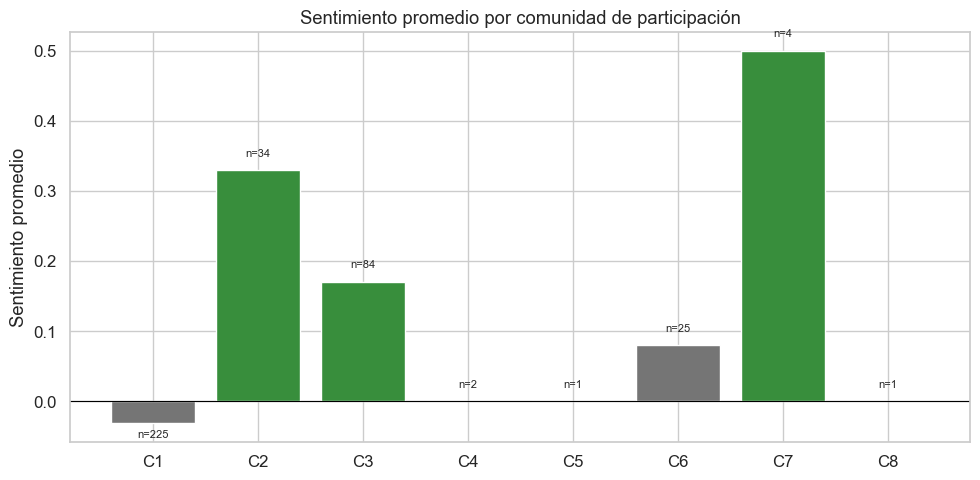

In [54]:
# Gráfico: sentimiento por comunidad
comm_data = []
for i, comm in enumerate(communities[:8]):
    vids_in_comm = list(comm)
    comms_in_comm = comments[comments['video_id'].isin(vids_in_comm)]
    sent = comms_in_comm['texto_limpio'].apply(sentimiento_simple).mean()
    comm_data.append({'Comunidad': f'C{i+1}', 'Sentimiento': sent,
                      'N comentarios': len(comms_in_comm)})

comm_df = pd.DataFrame(comm_data)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d32f2f' if s < -0.1 else '#388e3c' if s > 0.1 else '#757575'
          for s in comm_df['Sentimiento']]
ax.bar(comm_df['Comunidad'], comm_df['Sentimiento'], color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Sentimiento promedio')
ax.set_title('Sentimiento promedio por comunidad de participación')

# Anotar n comentarios
for i, row in comm_df.iterrows():
    ax.text(i, row['Sentimiento'] + 0.02 * (1 if row['Sentimiento'] >= 0 else -1),
            f"n={row['N comentarios']}", ha='center', fontsize=8)

plt.tight_layout()
plt.show()

**Interpretación (Q4).** Las comunidades detectadas muestran temáticas diferenciadas: la comunidad más grande (4 videos, 187 autores) gira en torno a política/corrupción (palabras: *pueblo, diputado, pagar, dinero*) con sentimiento ligeramente negativo (sent. = -0.03); otras comunidades, como la #2 (3 videos) y #6, presentan sentimiento claramente positivo (excelente, juego, iniciativa), asociadas a contenidos de gobierno/proyectos. Temas de *deportación e inmigración* (comunidad 4) y *ciudad/proyectos* (comunidad 5) forman estructuras más aisladas.

### Q5 — ¿La visibilidad medida mediante visualizaciones coincide con la participación observada?

In [55]:
# Videos virales (p90 de views) con 0 comentarios
p90_views = videos['view_count'].quantile(0.90)
virales = videos[videos['view_count'] >= p90_views]
virales_with_comments = virales.merge(
    comments.groupby('video_id').size().reset_index(name='n_comments'),
    on='video_id', how='left'
).fillna(0)

n_virales = len(virales)
n_virales_0comments = (virales_with_comments['n_comments'] == 0).sum()

print(f"Videos virales (≥percentil 90 de views, ≥{p90_views:,.0f} vistas): {n_virales}")
print(f"De estos, con 0 comentarios: {n_virales_0comments} ({n_virales_0comments/n_virales:.1%})")
print(f"De estos, con ≥1 comentario: {n_virales - n_virales_0comments}")

# Videos con muchos comentarios pero pocas views
p25_views = videos['view_count'].quantile(0.25)
low_views_high_comments = vid_stats[
    (vid_stats['view_count'] <= p25_views) & (vid_stats['n_comments'] >= 3)
]
print(f"\nVideos con views ≤ percentil 25 y ≥3 comentarios: {len(low_views_high_comments)}")
if len(low_views_high_comments) > 0:
    print(low_views_high_comments[['title', 'view_count', 'n_comments']].to_string(index=False))

Videos virales (≥percentil 90 de views, ≥51,319 vistas): 30
De estos, con 0 comentarios: 29 (96.7%)
De estos, con ≥1 comentario: 1

Videos con views ≤ percentil 25 y ≥3 comentarios: 0


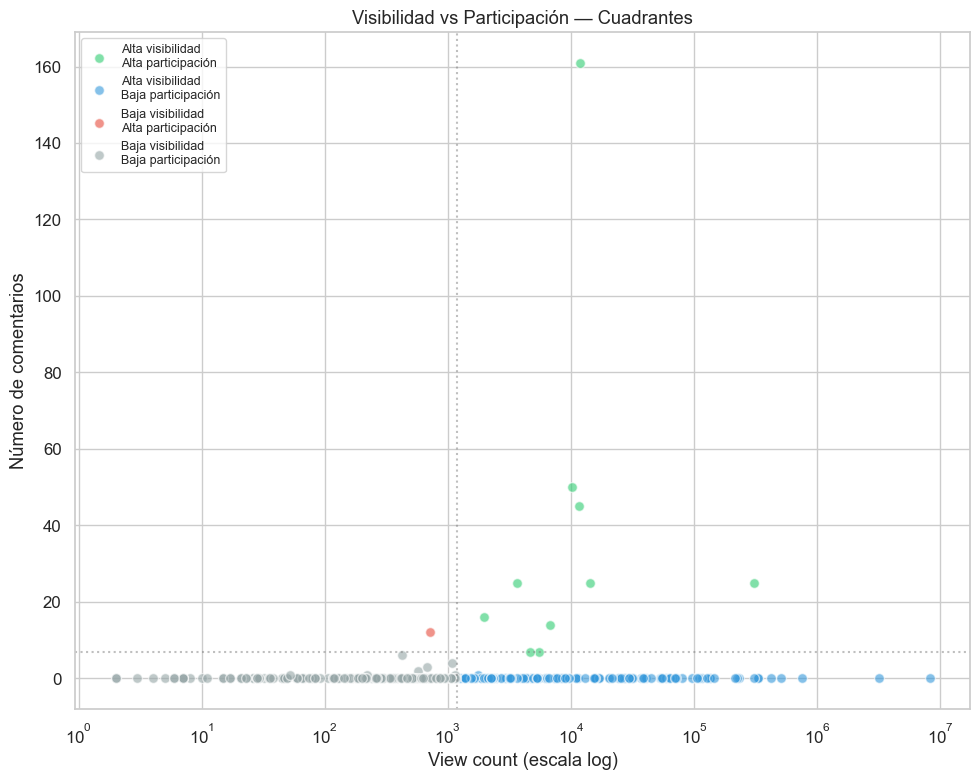

In [56]:
# Clasificar videos en 4 cuadrantes
med_views = vid_stats['view_count'].median()
med_comments = vid_stats[vid_stats['n_comments'] > 0]['n_comments'].median() if (vid_stats['n_comments'] > 0).any() else 0

def cuadrante(row):
    high_v = row['view_count'] >= med_views
    high_c = row['n_comments'] >= med_comments
    if high_v and high_c: return 'Alta visibilidad\nAlta participación'
    if high_v and not high_c: return 'Alta visibilidad\nBaja participación'
    if not high_v and high_c: return 'Baja visibilidad\nAlta participación'
    return 'Baja visibilidad\nBaja participación'

vid_stats['cuadrante'] = vid_stats.apply(cuadrante, axis=1)

fig, ax = plt.subplots(figsize=(10, 8))
palette = {'Alta visibilidad\nAlta participación': '#2ecc71',
           'Alta visibilidad\nBaja participación': '#3498db',
           'Baja visibilidad\nAlta participación': '#e74c3c',
           'Baja visibilidad\nBaja participación': '#95a5a6'}

for cuad, color in palette.items():
    mask = vid_stats['cuadrante'] == cuad
    ax.scatter(vid_stats.loc[mask, 'view_count'], vid_stats.loc[mask, 'n_comments'],
               label=cuad, alpha=0.6, s=50, color=color, edgecolors='white')

ax.set_xscale('log')
ax.axvline(med_views, color='gray', linestyle=':', alpha=0.5)
ax.axhline(med_comments, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('View count (escala log)')
ax.set_ylabel('Número de comentarios')
ax.set_title('Visibilidad vs Participación — Cuadrantes')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

**Interpretación (Q5).** La visibilidad medida por vistas **no coincide** con la participación observada: de los 30 videos más vistos (≥ percentil 90), 29 (96.7%) no tienen comentarios recolectados. Esto indica que muchos contenidos de alto alcance carecen de participación capturada en este dataset (por cobertura, no necesariamente por ausencia de actividad real), lo que limita la comparación directa visibilidad-participación a un subconjunto muy reducido de videos.

### Q6 — ¿Qué conclusiones están limitadas por el procedimiento de recolección y la cobertura de los datos?

**Limitaciones principales:**

1. **Cobertura parcial de comentarios:** Solo se capturaron 406 comentarios principales para 293 videos. El 62% de los videos (180 de 293) no tienen comentarios asociados, lo cual no significa que no los tengan, sino que no fueron recolectados. Esto limita cualquier conclusión sobre "participación ausente".

2. **Solo comentarios principales:** El scraping no captura respuestas a comentarios. La variable `reply_count` indica cuántas respuestas recibe un comentario, pero no identifica a los autores de esas respuestas ni su contenido. Por lo tanto, **no se puede construir una red de interacción usuario-usuario** — solo la red bipartita autor-video basada en comentarios principales.

3. **Fechas relativas:** `published_time` (videos) y `published_text` (comments) son textos dependientes del momento de scraping ("hace 2 días"), no fechas exactas. Cualquier análisis temporal fino está limitado, particularmente para los comentarios, donde no existe equivalente a `publish_date`.

4. **Sesgo de muestra por consultas:** Los videos fueron recuperados mediante búsquedas específicas (ver `source_query`), lo que introduce un sesgo temático y geográfico. No representan la totalidad de contenido de YouTube sobre Guatemala.

5. **Variables no utilizables:** `is_pinned` es constante (False) y `viewer_rating` es 100% nula, por lo que no aportan al análisis.

6. **Vistas incluyen tráfico no orgánico:** `view_count` puede incluir vistas de bots, reproducciones automáticas o vistas pagadas, sobreestimando la "popularidad real" de ciertos videos.

## 3.6 Preguntas adicionales

### P1 — ¿Los comentarios con más "me gusta" provienen de autores que participan en múltiples videos?

Promedio de likes por tipo de autor:
                      mean  median  count
tipo                                     
Multi-video (≥2)  0.703704     0.0      9
Single-video      6.819711     1.0    323

Mann-Whitney U test: U = 1045.0, p = 0.1317


C:\Users\adria\AppData\Local\Temp\ipykernel_31160\2951513268.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, labels=['Single-video', 'Multi-video'], patch_artist=True)


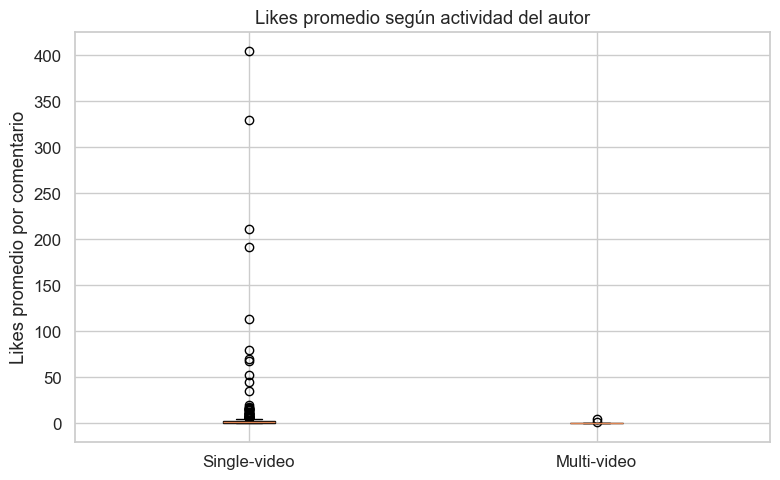

In [57]:
# Unir like_count con el conteo de videos por autor
author_activity = comments.groupby('author_channel_id').agg(
    n_videos=('video_id', 'nunique'),
    avg_likes=('like_count', 'mean'),
    total_likes=('like_count', 'sum'),
    n_comments=('comment_id', 'size')
).reset_index()

author_activity['tipo'] = author_activity['n_videos'].apply(
    lambda x: 'Multi-video (≥2)' if x >= 2 else 'Single-video'
)

print("Promedio de likes por tipo de autor:")
print(author_activity.groupby('tipo')['avg_likes'].agg(['mean', 'median', 'count']))

# Mann-Whitney U test
likes_multi = author_activity[author_activity['tipo'] == 'Multi-video (≥2)']['avg_likes']
likes_single = author_activity[author_activity['tipo'] == 'Single-video']['avg_likes']
if len(likes_multi) > 0 and len(likes_single) > 0:
    stat, pval_u = mannwhitneyu(likes_multi, likes_single, alternative='two-sided')
    print(f"\nMann-Whitney U test: U = {stat:.1f}, p = {pval_u:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
data_plot = [likes_single.values, likes_multi.values]
bp = ax.boxplot(data_plot, labels=['Single-video', 'Multi-video'], patch_artist=True)
bp['boxes'][0].set_facecolor('#3498db')
bp['boxes'][1].set_facecolor('#e74c3c')
ax.set_ylabel('Likes promedio por comentario')
ax.set_title('Likes promedio según actividad del autor')
plt.tight_layout()
plt.show()

### P2 — ¿Existen diferencias en la longitud del texto por categoría de video?

Longitud promedio de texto por categoría:
             category       mean  median  count
        Entertainment 147.414286   119.5     70
      News & Politics 137.946269    93.0    335
Nonprofits & Activism   2.000000     2.0      1


C:\Users\adria\AppData\Local\Temp\ipykernel_31160\334417202.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='category', x='text_len', order=order, ax=ax,


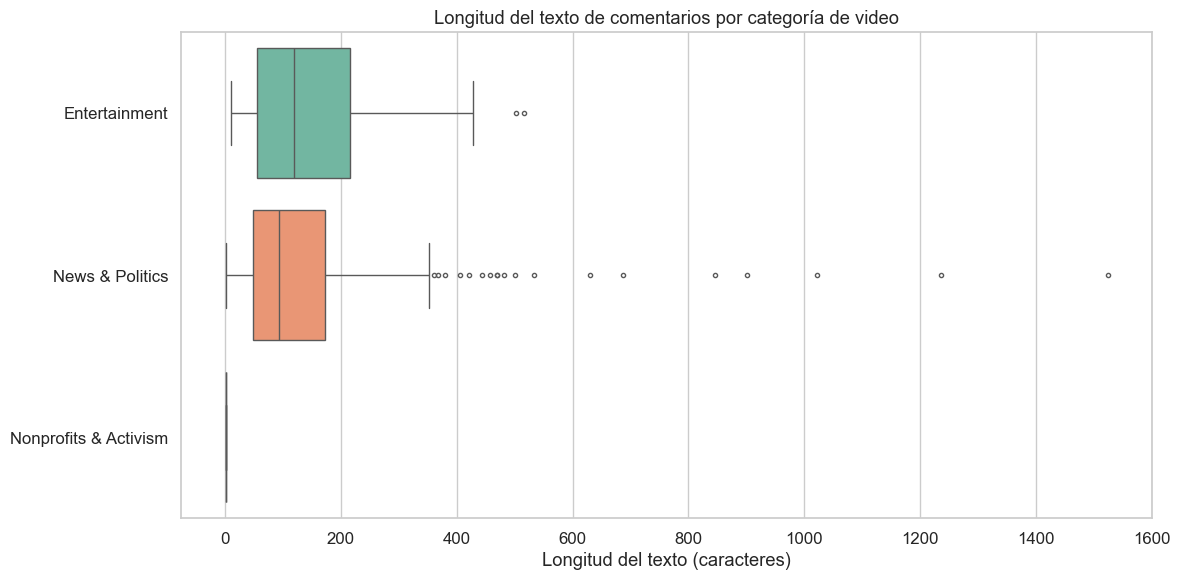

In [58]:
df['text_len'] = df['texto_original'].fillna('').str.len()

cat_lengths = df.groupby('category')['text_len'].agg(['mean', 'median', 'count']).reset_index()
cat_lengths = cat_lengths.sort_values('mean', ascending=False)
print("Longitud promedio de texto por categoría:")
print(cat_lengths.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
order = cat_lengths.sort_values('mean', ascending=False)['category'].tolist()
sns.boxplot(data=df, y='category', x='text_len', order=order, ax=ax,
            palette='Set2', fliersize=3)
ax.set_xlabel('Longitud del texto (caracteres)')
ax.set_ylabel('')
ax.set_title('Longitud del texto de comentarios por categoría de video')
plt.tight_layout()
plt.show()

### P3 — ¿Los canales oficiales generan más engagement que los no oficiales?

In [59]:
# source_group indica el tipo de fuente: topic, official_gov, channel
sg_stats = df.groupby('source_query_video').agg(
    n_comments=('comment_id', 'size'),
    avg_likes=('like_count', 'mean'),
    n_autores=('author_channel_id', 'nunique')
).reset_index()
sg_stats.columns = ['source_query', 'n_comments', 'avg_likes', 'n_autores']
sg_stats = sg_stats.sort_values('n_comments', ascending=False)

print("Engagement por consulta de búsqueda (source_query del video):")
print(sg_stats.head(10).to_string(index=False))

# Comparar source_group del video
sg_group = df.groupby('source_group_video').agg(
    n_comments=('comment_id', 'size'),
    avg_likes=('like_count', 'mean'),
    n_videos=('video_id', 'nunique'),
    avg_views=('view_count', 'mean')
).reset_index()
sg_group.columns = ['source_group', 'n_comments', 'avg_likes', 'n_videos', 'avg_views']
sg_group['comments_per_video'] = sg_group['n_comments'] / sg_group['n_videos']

print("\nEngagement por source_group:")
print(sg_group.to_string(index=False))

Engagement por consulta de búsqueda (source_query del video):
                         source_query  n_comments  avg_likes  n_autores
                            Quorum GT         162   2.209877        129
                   guatemala noticias          55   0.690909         47
                            @quorumgt          51   1.784314         50
Gobierno de la República de Guatemala          45   2.000000         32
                     @quorumgt/videos          43   0.720930         38
                 @GobiernodeGuatemala          25   0.800000         19
           Municipalidad de Guatemala          25  67.880000         25

Engagement por source_group:
source_group  n_comments  avg_likes  n_videos    avg_views  comments_per_video
     channel          43   0.720930         7  1200.325581            6.142857
       topic         363   6.319559        12 30695.181818           30.250000


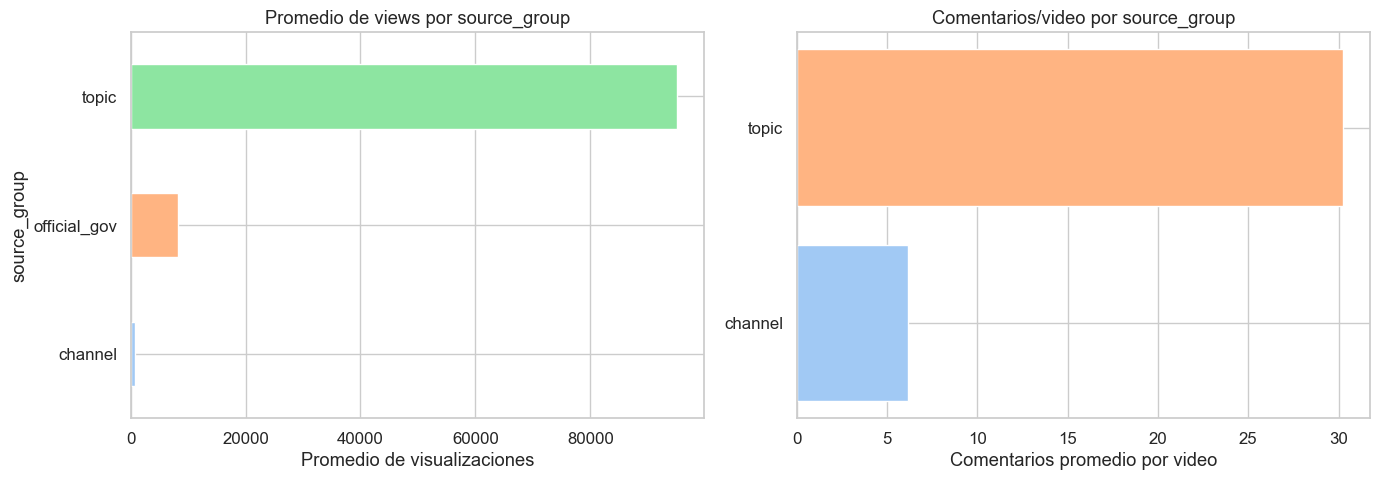

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Promedio de views por source_group
sg_v = videos.groupby('source_group')['view_count'].mean().sort_values()
sg_v.plot.barh(ax=axes[0], color=sns.color_palette('pastel', len(sg_v)))
axes[0].set_xlabel('Promedio de visualizaciones')
axes[0].set_title('Promedio de views por source_group')

# Comments per video por source_group
sg_c = sg_group.sort_values('comments_per_video')
axes[1].barh(sg_c['source_group'], sg_c['comments_per_video'],
             color=sns.color_palette('pastel', len(sg_c)))
axes[1].set_xlabel('Comentarios promedio por video')
axes[1].set_title('Comentarios/video por source_group')

plt.tight_layout()
plt.show()

## 4. Construcción de la red bipartita autor-video

### 4.1–4.3 Construcción de la red, tabla de nodos y tabla de aristas

Se construye una red **bipartita no dirigida** con dos tipos de nodo:

- **Autores** (`author_channel_id`): quienes publican comentarios.
- **Videos** (`video_id`): donde se publican esos comentarios.

Una arista conecta a un autor con un video cuando ese autor comentó en ese video, y su peso es el número de comentarios que ese autor publicó en ese video específico (no el número de "me gusta" ni de respuestas). Solo se incluyen en la red los videos que recibieron al menos un comentario en la muestra recolectada (19 de los 293 videos); los 274 videos restantes no tienen comentarios observados y por lo tanto no participan en esta red (ver limitación de cobertura, discutida más adelante en el inciso 10).

In [61]:
# --- Pesos de arista: número de comentarios de cada autor en cada video ---
pesos_arista = (
    comments.groupby(["author_channel_id", "video_id"])
    .size()
    .reset_index(name="n_comentarios")
)

print(f"Autores únicos: {comments['author_channel_id'].nunique()}")
print(f"Videos con al menos 1 comentario: {comments['video_id'].nunique()}")
print(f"Aristas autor-video (pares únicos): {len(pesos_arista)}")

Autores únicos: 332
Videos con al menos 1 comentario: 19
Aristas autor-video (pares únicos): 343


In [62]:
# --- Construcción del grafo bipartito ---
G_bip = nx.Graph()

autores_unicos = comments["author_channel_id"].unique()
videos_comentados = comments["video_id"].unique()

G_bip.add_nodes_from(autores_unicos, tipo="autor")
G_bip.add_nodes_from(videos_comentados, tipo="video")

for _, fila in pesos_arista.iterrows():
    G_bip.add_edge(
        fila["author_channel_id"], fila["video_id"], weight=fila["n_comentarios"]
    )

print(f"Nodos totales: {G_bip.number_of_nodes()} "
      f"({len(autores_unicos)} autores + {len(videos_comentados)} videos)")
print(f"Aristas totales: {G_bip.number_of_edges()}")
print(f"¿Es bipartita?: {nx.is_bipartite(G_bip)}")

Nodos totales: 351 (332 autores + 19 videos)
Aristas totales: 343
¿Es bipartita?: True


In [63]:
# --- Tabla de nodos (con atributos relevantes por tipo) ---
comentarios_por_autor = comments.groupby("author_channel_id").size()
videos_por_autor = comments.groupby("author_channel_id")["video_id"].nunique()
handle_por_autor = comments.groupby("author_channel_id")["author_handle"].first()

autores_nodos = pd.DataFrame({
    "node_id": autores_unicos,
    "tipo": "autor",
    "etiqueta": [handle_por_autor.get(a, a) for a in autores_unicos],
    "n_comentarios_totales": [comentarios_por_autor.get(a, 0) for a in autores_unicos],
    "n_videos_comentados": [videos_por_autor.get(a, 0) for a in autores_unicos],
})

info_video = videos.set_index("video_id")
comentarios_por_video = comments.groupby("video_id").size()
autores_por_video = comments.groupby("video_id")["author_channel_id"].nunique()

videos_nodos = pd.DataFrame({
    "node_id": videos_comentados,
    "tipo": "video",
    "etiqueta": [info_video.loc[v, "title"] if v in info_video.index else v for v in videos_comentados],
    "channel_name": [info_video.loc[v, "channel_name"] if v in info_video.index else None for v in videos_comentados],
    "category": [info_video.loc[v, "category"] if v in info_video.index else None for v in videos_comentados],
    "view_count": [info_video.loc[v, "view_count"] if v in info_video.index else None for v in videos_comentados],
    "n_comentarios_recibidos": [comentarios_por_video.get(v, 0) for v in videos_comentados],
    "n_autores_unicos": [autores_por_video.get(v, 0) for v in videos_comentados],
})

tabla_nodos = pd.concat([autores_nodos, videos_nodos], ignore_index=True)
print(f"Tabla de nodos: {len(tabla_nodos)} filas")
tabla_nodos.head(10)

Tabla de nodos: 351 filas


,node_id,tipo,etiqueta,n_comentarios_totales,n_videos_comentados,channel_name,category,view_count,n_comentarios_recibidos,n_autores_unicos
0,UCdFlugHJJa4l3YqWuNRmvXw,autor,/@MarcosCarillo-b1r,2.0,2.0,NaN,NaN,NaN,NaN,NaN
1,UCvl1tzQeBeGy6efPTRJXSCw,autor,/@RaulPerez-cw2vi,1.0,1.0,NaN,NaN,NaN,NaN,NaN
2,UCRAquv8el-tQ30bN7MlmySQ,autor,/@iamjimalesssa,1.0,1.0,NaN,NaN,NaN,NaN,NaN
3,UCkbsS_3D-pvg1iHOld9uvIg,autor,/@gonzalo6075,1.0,1.0,NaN,NaN,NaN,NaN,NaN
4,UCOLHH4ZpMxPYF-Q6e6wvn5A,autor,/@luisroldan7374,1.0,1.0,NaN,NaN,NaN,NaN,NaN
5,UCi2KiZq63sRq8Mfbcp-MelQ,autor,/@eugeneramirez4405,6.0,1.0,NaN,NaN,NaN,NaN,NaN
6,UCXl30Y_upRqbti52fmjK4YA,autor,/@capitanfrans,1.0,1.0,NaN,NaN,NaN,NaN,NaN
7,UCRelkU8JiZBytTzebJxaa-w,autor,/@danyraymundo2942,1.0,1.0,NaN,NaN,NaN,NaN,NaN
8,UCgLurCo-e019HGODcjXHWCw,autor,/@perritojuega1,1.0,1.0,NaN,NaN,NaN,NaN,NaN
9,UCDIMztpVm7G27qBuiWuT6oQ,autor,/@lizardomorataya8274,1.0,1.0,NaN,NaN,NaN,NaN,NaN


In [65]:
# --- Tabla de aristas ---
tabla_aristas = pesos_arista.merge(
    handle_por_autor.rename("author_handle"), on="author_channel_id", how="left"
).merge(
    videos[["video_id", "title"]].rename(columns={"title": "video_title"}),
    on="video_id", how="left"
).rename(columns={"n_comentarios": "weight"})

tabla_aristas = tabla_aristas[
    ["author_channel_id", "author_handle", "video_id", "video_title", "weight"]
]
print(f"Tabla de aristas: {len(tabla_aristas)} filas")
tabla_aristas.sort_values("weight", ascending=False).head(10)

Tabla de aristas: 343 filas


,author_channel_id,author_handle,video_id,video_title,weight
244,UCi2KiZq63sRq8Mfbcp-MelQ,/@eugeneramirez4405,OkXlHx0hx-8,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México...,6
331,UCyJhqmMbsvjpoarBBStA2kg,/@Murmullodelbarrio,6W4u8sGEnGM,Inician los trabajos de recuperación del Puente Belice II.,6
33,UC5H8ASmMC9WrURmzeB4ySog,/@ManuelEdran,n8iP75gIpmw,Qué rico come tu diputado,5
165,UCV3fr-YOixFKCZBbJP1-X4w,/@albertoshernandez5251,6W4u8sGEnGM,Inician los trabajos de recuperación del Puente Belice II.,5
57,UC9vMq1YF-e7C-VO0SHkbUTA,/@ErvinLeonardoCarreraLat%C3%ADn,n8iP75gIpmw,Qué rico come tu diputado,4
25,UC3XTwHxygNCgjndsg-UiCQA,/@marioajset4283,n8iP75gIpmw,Qué rico come tu diputado,3
46,UC72gBAtyb_VXQlYDcFrh6oQ,/@osmanmorales3012,n8iP75gIpmw,Qué rico come tu diputado,3
85,UCFjudnPLoaSL1BaRuLahyHg,/@HaroldoCastillo-rh9iw,n8iP75gIpmw,Qué rico come tu diputado,3
120,UCNIeXbV_mEwpa412h1aqUWw,/@juandeleon9060,PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,3
226,UCg3eIfd7BrsLEqS0BLkftHA,/@ErmeP%C3%A9rez-q4s,PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,3


In [66]:
# --- Guardar tablas para reproducibilidad ---
tabla_nodos.to_csv("data/red_bipartita_nodos.csv", index=False)
tabla_aristas.to_csv("data/red_bipartita_aristas.csv", index=False)
print("Guardado: data/red_bipartita_nodos.csv, data/red_bipartita_aristas.csv")

Guardado: data/red_bipartita_nodos.csv, data/red_bipartita_aristas.csv


### 4.4 Visualización de la red completa

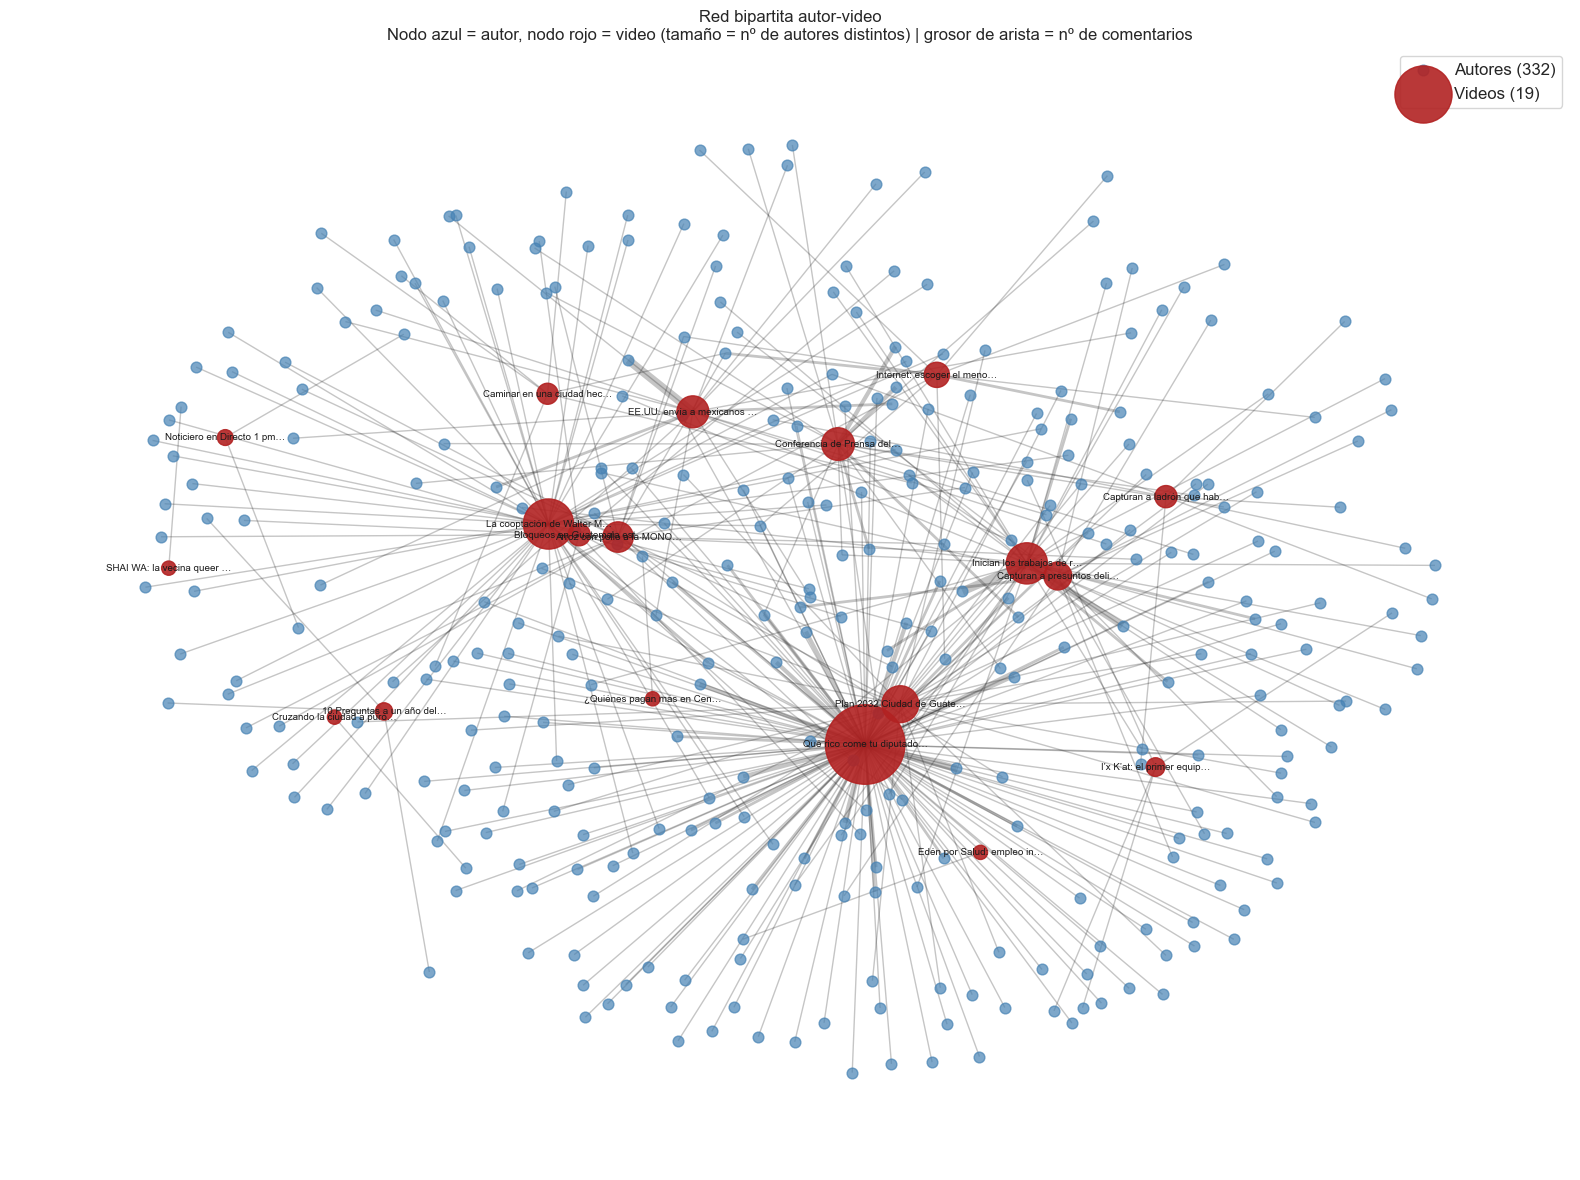

In [67]:
fig, ax = plt.subplots(figsize=(16, 12))

pos = nx.spring_layout(G_bip, k=0.4, seed=RANDOM_STATE, iterations=60)

nodos_autor = [n for n, d in G_bip.nodes(data=True) if d["tipo"] == "autor"]
nodos_video = [n for n, d in G_bip.nodes(data=True) if d["tipo"] == "video"]

pesos_aristas_dibujo = [G_bip[u][v]["weight"] for u, v in G_bip.edges()]

nx.draw_networkx_edges(G_bip, pos, alpha=0.25, width=pesos_aristas_dibujo, ax=ax)
nx.draw_networkx_nodes(
    G_bip, pos, nodelist=nodos_autor, node_color="steelblue",
    node_size=60, alpha=0.7, label=f"Autores ({len(nodos_autor)})", ax=ax
)
nx.draw_networkx_nodes(
    G_bip, pos, nodelist=nodos_video, node_color="firebrick",
    node_size=[80 + 25 * G_bip.degree(v) for v in nodos_video],
    alpha=0.9, label=f"Videos ({len(nodos_video)})", ax=ax
)

# Etiquetas solo para los videos (los autores son demasiados para etiquetar legiblemente)
labels_video = {v: (info_video.loc[v, "title"][:25] + "…" if v in info_video.index else v) for v in nodos_video}
nx.draw_networkx_labels(G_bip, pos, labels=labels_video, font_size=7, ax=ax)

ax.set_title(
    "Red bipartita autor-video\n"
    "Nodo azul = autor, nodo rojo = video (tamaño = nº de autores distintos) "
    "| grosor de arista = nº de comentarios",
    fontsize=12,
)
ax.legend(scatterpoints=1, loc="upper right")
ax.axis("off")
plt.tight_layout()
plt.savefig("data/red_bipartita_autor_video.png", dpi=150)
plt.show()

### 4.5 Qué significa (y qué NO significa) una arista

Una arista entre un autor y un video indica únicamente que ese autor publicó al menos un comentario en ese video, y su peso es cuántos comentarios publicó allí. Esto es co-participación observada en el mismo espacio de comentarios, no una interacción entre personas: los datos no identifican quién respondió a quién (`reply_count` solo indica cuántas respuestas recibió un comentario, no sus autores), así que una arista no debe interpretarse como conversación directa, amistad, acuerdo o aprobación entre el autor y el canal, ni entre dos autores que comentaron el mismo video. Dos autores conectados al mismo video pueden no haberse visto nunca ni haber interactuado entre sí;
lo único verificable es que ambos dejaron un comentario visible bajo el mismo contenido.